# ***PROJECT : A Real Time Application For Gender And Age Detector***

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from PIL import Image
from tensorflow.keras.utils import plot_model # type: ignore
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import Dropout, Input, Add, Dense, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model, load_model
import warnings
warnings.filterwarnings("ignore", message=".*CuDNN.*")
warnings.filterwarnings("ignore", message=".*cuFFT.*")
warnings.filterwarnings("ignore", message=".*cuBLAS.*")
import os
# from tensorflow.keras.utils import np_utils
from tensorflow.keras import utils
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import datasets, layers, models
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Internship_Datasets/UTK_Face_Dataset.zip"
extract_path = "/content/utkface"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
print(os.listdir("/content/utkface"))

['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [ ]:
BASE_DIRS = ["/content/utkface/UTKFace"]

In [ ]:
image_paths = []
age_labels = []
gender_paths = []

for BASE_DIR in BASE_DIRS:
    for filename in tqdm(os.listdir(BASE_DIR)):
        temp = filename.split('_')
        if temp[0].isdigit():  # Check if the first part of the filename is a number
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(BASE_DIR, filename)
            image_paths.append(image_path)
            age_labels.append(age)
            gender_paths.append(gender)

100%|██████████| 23708/23708 [00:00<00:00, 577463.05it/s]


In [ ]:
df =pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths,age_labels,gender_paths
df.head()
# print(df.head())
print(f"Dataframe: {df}")
gender_dict = {0:'Male', 1:'Female'}



Dataframe:                                                    image  age  gender
0      /content/utkface/UTKFace/25_1_1_20170114030648...   25       1
1      /content/utkface/UTKFace/35_0_2_20170117122032...   35       0
2      /content/utkface/UTKFace/21_1_1_20170114031500...   21       1
3      /content/utkface/UTKFace/28_1_1_20170112222231...   28       1
4      /content/utkface/UTKFace/26_0_1_20170117154145...   26       0
...                                                  ...  ...     ...
23703  /content/utkface/UTKFace/35_0_0_20170117145856...   35       0
23704  /content/utkface/UTKFace/75_0_0_20170117174632...   75       0
23705  /content/utkface/UTKFace/34_0_4_20170104201954...   34       0
23706  /content/utkface/UTKFace/9_0_0_201701102207129...    9       0
23707  /content/utkface/UTKFace/41_1_0_20170109140858...   41       1

[23708 rows x 3 columns]


Dataframe shape: (23708, 3)
First few rows of the dataframe:                                                image  age  gender
0  /content/utkface/UTKFace/25_1_1_20170114030648...   25       1
1  /content/utkface/UTKFace/35_0_2_20170117122032...   35       0
2  /content/utkface/UTKFace/21_1_1_20170114031500...   21       1
3  /content/utkface/UTKFace/28_1_1_20170112222231...   28       1
4  /content/utkface/UTKFace/26_0_1_20170117154145...   26       0


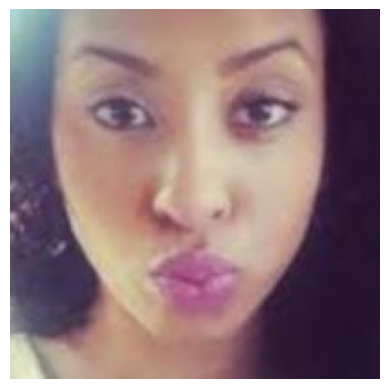

In [ ]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_paths

# Debug print to check if the dataframe is populated correctly
print(f"Dataframe shape: {df.shape}")
print(f"First few rows of the dataframe: {df.head()}")

if not df.empty:
    gender_dict = {0: 'Male', 1: 'Female'}

    try:
        img = Image.open(df['image'][0])
        plt.axis('off')
        plt.imshow(img)
        plt.show()
    except Exception as e:
        print(f"Error opening image: {e}")
else:
    print("Dataframe is empty. No images found.")

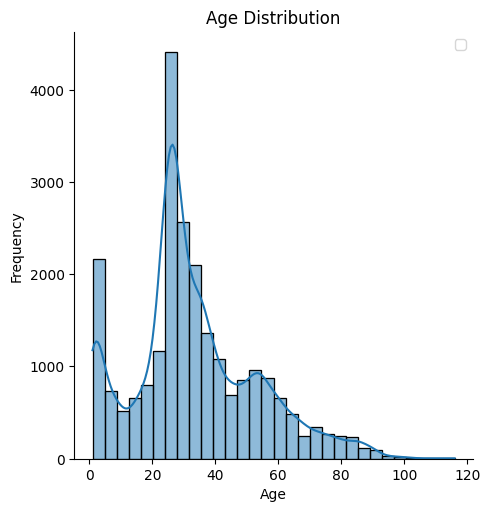

In [ ]:
sns.displot(df['age'],kde=True, bins=30)
plt.title('Age Distribution')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.figure(figsize=(25,25))
files = df.iloc[0:25]

<Figure size 2500x2500 with 0 Axes>

In [ ]:
def extract_feature(images):
    features = []
    for image in tqdm(images):
        # Load image and convert to grayscale
        img = Image.open(image).convert('L')
        # Resize image
        img = img.resize((128, 128), Image.BILINEAR)  # Use Image.ANTIALIAS

        img = np.array(img)
        features.append(img)

    features = np.array(features)

    features = features.reshape(len(features), 128, 128, 1)
    return features

In [ ]:
X = extract_feature(df['image'])

print(f"X_shape: \t{X.shape}")
X = X / 255.0 #normalize the  image

y_gender = np.array(df['gender'])
y_age = np.array(df['age'])
print("Shape of y_gender:", y_gender.shape)
print("Shape of y_age:", y_age.shape)

100%|██████████| 23708/23708 [00:16<00:00, 1443.88it/s]


X_shape: 	(23708, 128, 128, 1)
Shape of y_gender: (23708,)
Shape of y_age: (23708,)


In [ ]:
input_shape = (128,128,1)

inputs = Input(input_shape)

#convolution layers
conv1 = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
maxp1 = MaxPooling2D(pool_size=(2, 2))(conv1)

conv2 = Conv2D(64, kernel_size=(3, 3), activation='relu')(maxp1)
maxp2 = MaxPooling2D(pool_size=(2, 2))(conv2)

conv3 = Conv2D(128, kernel_size=(3, 3), activation='relu')(maxp2)
maxp3 = MaxPooling2D(pool_size=(2, 2))(conv3)

conv4 = Conv2D(256, kernel_size=(3, 3), activation='relu')(maxp3)
maxp4 = MaxPooling2D(pool_size=(2, 2))(conv4)

flatten = Flatten()(maxp4)

# Fully connected layers

dense1 = Dense(256, activation='relu')(flatten)
dense2 = Dense(256, activation='relu')(flatten)

dropout1 = Dropout(0.3)(dense1)
dropout2 = Dropout(0.3)(dense2)

# Output layers
output1 = Dense(1, activation='sigmoid', name='gender_out')(dropout1)
output2 = Dense(1, activation='relu', name='age_out')(dropout2)

model = Model(inputs=inputs, outputs=[output1, output2])


model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Concatenate y_gender and y_age into a single array
y_combined = np.column_stack((y_gender, y_age))

# Split the dataset into training and temporary sets
X_train, X_temp, y_combined_train, y_combined_temp = train_test_split(X, y_combined, test_size=0.2, random_state=42)

# Từ phần còn lại, chia thành 50% testing và 50% validation
X_test, X_val, y_combined_test, y_combined_val = train_test_split(X_temp, y_combined_temp, test_size=0.5, random_state=42)

# Split y_combined back into y_gender and y_age
y_train_gender, y_train_age = y_combined_train[:, 0], y_combined_train[:, 1]
y_test_gender, y_test_age = y_combined_test[:, 0], y_combined_test[:, 1]
y_val_gender, y_val_age = y_combined_val[:, 0], y_combined_val[:, 1]

In [ ]:
from keras.callbacks import LearningRateScheduler

model_path = '/content/drive/MyDrive/Internship_Datasets/TASK_1_Models/best_model.keras'

checkpointer = ModelCheckpoint(
    filepath=model_path,
    monitor='val_gender_out_accuracy',
    verbose=1,
    mode='max',
    save_best_only=True
)

model.compile(loss=['binary_crossentropy', 'mae'],
              optimizer='adam',
              metrics=['accuracy', 'mae'])

annealer = LearningRateScheduler(lambda x: 1e-3 * 0.9 ** x)

In [ ]:
total_images = len(image_paths)
print(f"Total number of images: {total_images}")

# Compute number of images in each set
train_images = len(X_train)
validation_images = len(X_val)
test_images = len(X_test)

print(f"Number of training images: {train_images}")
print(f"Number of validation images: {validation_images}")
print(f"Number of test images: {test_images}")


Total number of images: 23708
Number of training images: 18966
Number of validation images: 2371
Number of test images: 2371


In [ ]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)

# Training model
history = model.fit(x=X_train, y=[y_train_gender, y_train_age], batch_size=128, epochs=100, validation_data=(X_val, [y_val_gender, y_val_age]),callbacks = [annealer, checkpointer])

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - age_out_loss: 18.5814 - age_out_mae: 18.5814 - gender_out_accuracy: 0.5310 - gender_out_loss: 0.7497 - loss: 19.3312
Epoch 1: val_gender_out_accuracy improved from None to 0.60607, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 186ms/step - age_out_loss: 16.3908 - age_out_mae: 16.3908 - gender_out_accuracy: 0.5417 - gender_out_loss: 0.7070 - loss: 17.0977 - val_age_out_loss: 14.3797 - val_age_out_mae: 14.3797 - val_gender_out_accuracy: 0.6061 - val_gender_out_loss: 0.6656 - val_loss: 15.0453 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - age_out_loss: 14.0668 - age_out_mae: 14.0668 - gender_out_accuracy: 0.6387 - gender_out_loss: 0.6316 - loss: 14.6984
Epoch 2: val_gender_out_accuracy improved from 0.60607 to 0.76170, saving model to ./best_model.keras

Epoch 2: finished saving model to ./best_model.keras
149/149 ━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/Internship_Datasets/TASK_1_Models/best_model.keras"

model = load_model(model_path)

print("Model loaded successfully! ✅")

In [ ]:
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

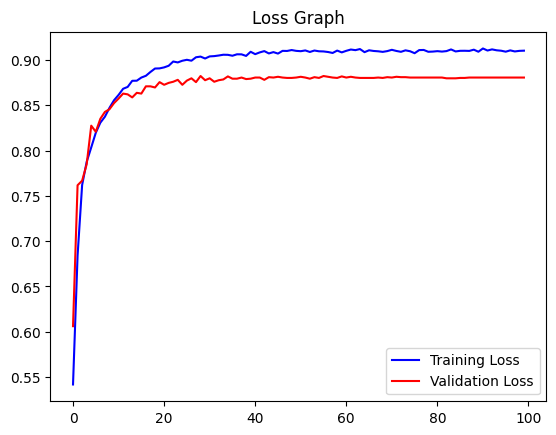

In [ ]:
plt.plot(epochs, acc, 'b', label='Training Loss')
plt.plot(epochs, val_acc, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

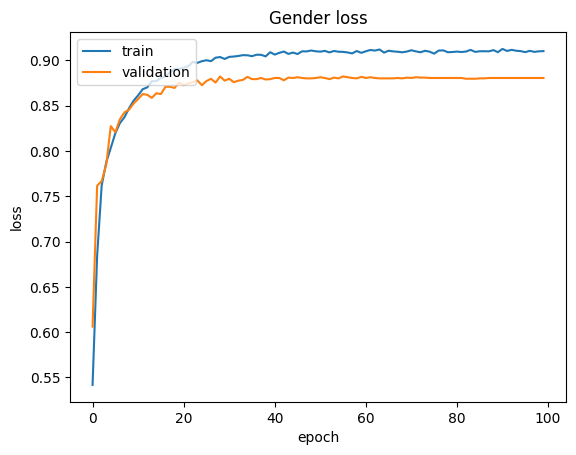

In [ ]:
plt.plot(history.history['gender_out_accuracy'])
plt.plot(history.history['val_gender_out_accuracy'])
plt.title('Gender loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


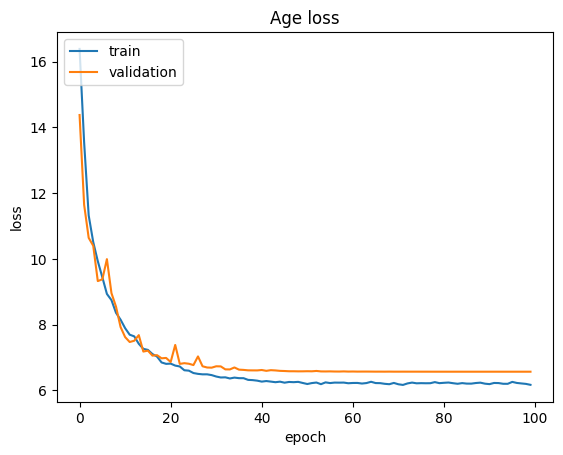

In [ ]:
plt.plot(history.history['age_out_mae'])
plt.plot(history.history['val_age_out_mae'])
plt.title('Age loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


Original Gender: 	Female 	 Original Age: 	15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Predicted Gender: 	Female	 Predicted Age 	22


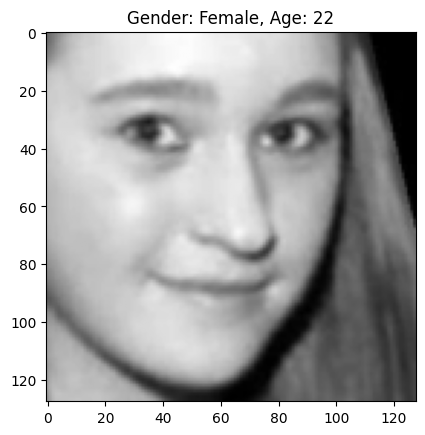

In [ ]:
image_index = 3000
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(X[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(X[image_index].reshape(128,128), cmap='gray')
plt.show()


Original Gender: 	Female 	 Original Age: 	27
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Gender: 	Female	 Predicted Age 	35


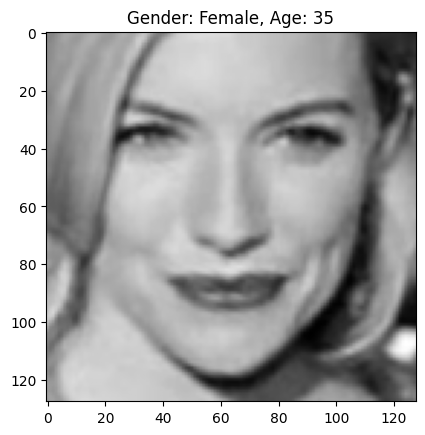

In [ ]:
image_index = 50
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(X[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(X[image_index].reshape(128,128), cmap='gray')
plt.show()

Original Gender: 	Female 	 Original Age: 	20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Gender: 	Male	 Predicted Age 	36


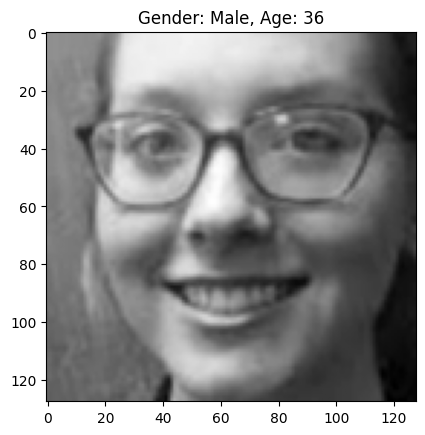

In [ ]:
image_index = 35
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(X[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(X[image_index].reshape(128,128), cmap='gray')
plt.show()

# ***TASK - 1 : Long Hair Identification***

***TO RUN GUI : FIX OPENCV FOR TASK 1 → OpenCV version + face_cascade setup → TASK 1 - LOAD REQUIRED FUNCTIONS → crop_face_for_model() → improved_hair_analysis() → final_task1_prediction() → webcam_task1() → Install Gradio → import gradio as gr → Gradio Blocks – Long Hair Identification System → final_demo.launch()***

In [ ]:
import os

print("Dataset folder exists:",
      os.path.exists("/content/utkface/UTKFace"))

if os.path.exists("/content/utkface/UTKFace"):
    files = os.listdir("/content/utkface/UTKFace")
    print("Number of images:", len(files))
    print("First image:", files[0])

Dataset folder exists: True
Number of images: 23708
First image: 49_1_0_20170109220434368.jpg.chip.jpg


In [ ]:
# ============================================================
# TASK 1 - OPENCV SETUP
# ============================================================

import cv2

print("OpenCV version:", cv2.__version__)

if cv2.__version__.startswith("4.11"):
    print("✅ OpenCV is ready for Task 1.")
else:
    print("⚠️ Current OpenCV version:", cv2.__version__)

In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:", hasattr(cv2, "CascadeClassifier"))

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("✅ Face detector ready!")

OpenCV version: 4.11.0
CascadeClassifier available: True
✅ Face detector ready!


In [ ]:
# ============================================================
# TASK 1 - LOAD REQUIRED FUNCTIONS
# ============================================================

import cv2
import numpy as np
from PIL import Image


def crop_face_for_model(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,
        minNeighbors=3,
        minSize=(50, 50)
    )

    if len(faces) > 0:

        x, y, w, h = max(
            faces,
            key=lambda f: f[2] * f[3]
        )

        margin = int(0.15 * max(w, h))

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(image.shape[1], x + w + margin)
        y2 = min(image.shape[0], y + h + margin)

        cropped_face = image[y1:y2, x1:x2]

    else:
        cropped_face = image

    cropped_path = "/content/task1_face.jpg"

    cv2.imwrite(
        cropped_path,
        cropped_face
    )

    return cropped_path


def improved_hair_analysis(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return "Unknown", 0.0

    h, w = image.shape[:2]

    left_region = image[
        int(h * 0.20):int(h * 0.90),
        int(w * 0.05):int(w * 0.40)
    ]

    right_region = image[
        int(h * 0.20):int(h * 0.90),
        int(w * 0.60):int(w * 0.95)
    ]

    left_hsv = cv2.cvtColor(
        left_region,
        cv2.COLOR_BGR2HSV
    )

    right_hsv = cv2.cvtColor(
        right_region,
        cv2.COLOR_BGR2HSV
    )

    def hair_ratio(hsv):

        H = hsv[:, :, 0]
        S = hsv[:, :, 1]
        V = hsv[:, :, 2]

        hair_pixels = (
            (S > 25) &
            (V < 190) &
            (V > 20)
        )

        return np.mean(hair_pixels)

    left_score = hair_ratio(left_hsv)
    right_score = hair_ratio(right_hsv)

    hair_score = (
        left_score + right_score
    ) / 2

    if hair_score >= 0.12:
        hair_status = "Possible Long/Extended Hair"
    else:
        hair_status = "Possible Short Hair"

    return hair_status, hair_score


print("✅ Task 1 functions loaded successfully!")

In [ ]:
def crop_face_for_model(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,
        minNeighbors=3,
        minSize=(50, 50)
    )

    # If face is detected
    if len(faces) > 0:

        x, y, w, h = max(
            faces,
            key=lambda f: f[2] * f[3]
        )

        margin = int(0.15 * max(w, h))

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(image.shape[1], x + w + margin)
        y2 = min(image.shape[0], y + h + margin)

        cropped_face = image[y1:y2, x1:x2]

    else:

        # Fallback: use the complete image
        # This prevents the prediction from returning None
        cropped_face = image

    cropped_path = "/content/task1_face.jpg"

    cv2.imwrite(
        cropped_path,
        cropped_face
    )

    return cropped_path

In [ ]:
def improved_hair_analysis(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return "Unknown", 0.0

    h, w = image.shape[:2]

    # Focus mainly on the left and right sides of the person
    # where long hair extends below the face.
    left_region = image[
        int(h * 0.20):int(h * 0.90),
        int(w * 0.05):int(w * 0.40)
    ]

    right_region = image[
        int(h * 0.20):int(h * 0.90),
        int(w * 0.60):int(w * 0.95)
    ]

    # Convert to HSV
    left_hsv = cv2.cvtColor(left_region, cv2.COLOR_BGR2HSV)
    right_hsv = cv2.cvtColor(right_region, cv2.COLOR_BGR2HSV)

    def hair_ratio(hsv):

        H = hsv[:, :, 0]
        S = hsv[:, :, 1]
        V = hsv[:, :, 2]

        # Brown / dark hair generally has noticeable saturation
        # and is darker than the background.
        hair_pixels = (
            (S > 25) &
            (V < 190) &
            (V > 20)
        )

        return np.mean(hair_pixels)

    left_score = hair_ratio(left_hsv)
    right_score = hair_ratio(right_hsv)

    hair_score = (left_score + right_score) / 2

    # Lower threshold so brown hair is detected
    if hair_score >= 0.12:
        hair_status = "Possible Long/Extended Hair"
    else:
        hair_status = "Possible Short Hair"

    return hair_status, hair_score

In [ ]:
def final_task1_prediction(image_path):

    # ---------- LOAD IMAGE ----------
    original_image = cv2.imread(image_path)

    if original_image is None:
        print("❌ Image could not be loaded.")
        return None

    # ---------- TRY FACE CROP ----------
    face_path = crop_face_for_model(image_path)

    # If face crop fails, use original image
    if face_path is not None:
        model_image = cv2.imread(face_path)
    else:
        model_image = original_image

    if model_image is None:
        model_image = original_image

    # ---------- AGE + GENDER ----------
    gray = cv2.cvtColor(model_image, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))

    img_array = gray.astype("float32") / 255.0
    img_array = img_array.reshape(1, 128, 128, 1)

    prediction = model.predict(
        img_array,
        verbose=0
    )

    model_gender = (
        "Female" if prediction[0][0][0] >= 0.5
        else "Male"
    )

    predicted_age = float(
        prediction[1][0][0]
    )

    # ---------- HAIR ANALYSIS ----------
    hair_status, hair_score = improved_hair_analysis(
        image_path
    )

    # ---------- TASK 1 LOGIC ----------
    if 20 <= predicted_age <= 30:

        age_condition = "Within 20–30"
        hair_influence = "Applied"

        if hair_status == "Possible Long/Extended Hair":
            final_gender = "Female"
        else:
            final_gender = "Male"

    else:

        age_condition = "Outside 20–30"
        hair_influence = "Not applied"

        final_gender = model_gender

    # ---------- RESULT ----------
    print("\n" + "=" * 50)
    print("          TASK 1 FINAL RESULT")
    print("=" * 50)

    print(f"Age              : {predicted_age:.2f}")
    print(f"Model Gender     : {model_gender}")
    print(f"Hair Status      : {hair_status}")
    print(f"Hair Score       : {hair_score:.3f}")
    print(f"Age Condition    : {age_condition}")
    print(f"Hair Influence   : {hair_influence}")
    print(f"Gender Decision  : {final_gender}")

    print("=" * 50)

    return {
        "age": predicted_age,
        "gender": final_gender,
        "model_gender": model_gender,
        "hair": hair_status,
        "hair_score": hair_score,
        "age_condition": age_condition,
        "hair_influence": hair_influence
    }

In [ ]:
def webcam_task1(image_path):

    if image_path is None:
        return "Please upload or capture an image."

    try:

        result = final_task1_prediction(image_path)

        if result is None:
            return """
❌ Prediction could not be completed.

Please make sure the uploaded image contains a clear face.
"""

        output = f"""
TASK 1 - LONG HAIR IDENTIFICATION

Age              : {result["age"]:.2f}
Model Gender     : {result["model_gender"]}
Hair Status      : {result["hair"]}
Hair Score       : {result["hair_score"]:.3f}

Age Condition    : {result["age_condition"]}
Hair Influence   : {result["hair_influence"]}

Final Gender     : {result["gender"]}
"""

        return output

    except Exception as e:

        return f"""
❌ TASK 1 ERROR

Error Type:
{type(e).__name__}

Error Message:
{str(e)}
"""

In [ ]:
!pip -q install gradio

In [ ]:
import gradio as gr

# Close previous GUI if it is already running
try:
    final_demo.close()
except:
    pass

with gr.Blocks(title="Long Hair Identification System") as final_demo:

    gr.Markdown("""
    # 🧑‍💻 Long Hair Identification System
    ### Age, Gender & Hair Analysis

    Upload an image or capture one using your webcam.
    The system predicts age and gender, analyzes hair,
    and applies the 20–30 age condition.
    """)

    with gr.Row():

        with gr.Column():
            input_image = gr.Image(
                sources=["upload", "webcam"],
                type="filepath",
                label="📷 Upload / Capture Image"
            )

            predict_button = gr.Button(
                "🔍 Analyze Image",
                variant="primary"
            )

        with gr.Column():
            output_text = gr.Textbox(
                label="📊 Task 1 Result",
                lines=12,
                interactive=False
            )

    gr.Markdown("""
    ### 📌 Task Logic

    - **Age 20–30 + Long Hair → Female**
    - **Age 20–30 + Short Hair → Male**
    - **Age outside 20–30 → Hair does not influence gender**
    """)

    predict_button.click(
        fn=webcam_task1,
        inputs=input_image,
        outputs=output_text
    )

final_demo.launch(share=True, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d55da402f886c9cd59.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ***TASK - 2 : Senior Citizen Identification***

***TO RUN GUI : SENIOR CITIZEN IDENTIFICATION → Install OpenCV → FACE DETECTION → LOAD SAVED AGE + GENDER MODEL → AGE + GENDER PREDICTION FUNCTION → LOAD SAVED SENIOR CITIZEN MODEL →  COMBINED FACE + AGE + GENDER + SENIOR DETECTION →  RECREATE FACE DETECTION FUNCTION →  process_video_fast FUNCTION →  generate_task2_report FUNCTION →  Install Gradio + Imports → task2_gui_process FUNCTION →  FINAL GUI (Gradio launch cell)***

In [ ]:
# TASK 2 - SENIOR CITIZEN IDENTIFICATION

import cv2
import os
import pandas as pd
from datetime import datetime

print("Task 2 libraries loaded successfully!")

Task 2 libraries loaded successfully!


In [ ]:
!pip install -q opencv-python==4.11.0.86

In [ ]:
# TASK 2 - FACE DETECTION

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Face detector created successfully! ✅")

Face detector created successfully! ✅


In [ ]:
# TASK 2 - PREPARE TEST DATA FOR ACCURACY EVALUATION

import os
import numpy as np
from PIL import Image

dataset_path = "/content/utkface/UTKFace"

X_test_images = []
y_senior_test = []

for file_name in X_test:

    # Get filename only
    file_name = os.path.basename(str(file_name))

    # Full image path
    image_path = os.path.join(dataset_path, file_name)

    # Read image
    img = Image.open(image_path).convert("L")
    img = img.resize((128, 128))

    # Normalize
    img_array = np.array(img, dtype=np.float32) / 255.0

    X_test_images.append(img_array)

    # Age is the first value in UTKFace filename
    age = int(file_name.split("_")[0])

    # Senior = age > 60
    y_senior_test.append(1 if age > 60 else 0)

X_test_images = np.array(X_test_images)
y_senior_test = np.array(y_senior_test)

# Add channel dimension
X_test_images = X_test_images.reshape(-1, 128, 128, 1)

print("Test images shape:", X_test_images.shape)
print("Senior labels shape:", y_senior_test.shape)
print("Senior citizens in test set:", np.sum(y_senior_test))

Test images shape: (2371, 128, 128, 1)
Senior labels shape: (2371,)
Senior citizens in test set: 232


In [ ]:
# TASK 2 - RETRAIN SENIOR CITIZEN MODEL WITH CLASS WEIGHTS

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

dataset_path = "/content/utkface/UTKFace"

# --------------------------------------------------
# 1. CREATE LABELS FROM UTKFace FILENAMES
# --------------------------------------------------

def get_senior_label(filename):
    filename = os.path.basename(str(filename))
    age = int(filename.split("_")[0])
    return 1 if age > 60 else 0

y_train_senior = np.array([get_senior_label(x) for x in X_train])
y_val_senior   = np.array([get_senior_label(x) for x in X_val])

# --------------------------------------------------
# 2. CREATE FULL IMAGE PATHS
# --------------------------------------------------

def get_full_path(filename):
    filename = os.path.basename(str(filename))
    return os.path.join(dataset_path, filename)

train_paths = np.array([get_full_path(x) for x in X_train])
val_paths   = np.array([get_full_path(x) for x in X_val])

# --------------------------------------------------
# 3. CLASS WEIGHTS
# --------------------------------------------------

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_senior
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:", class_weights)
print("Training samples:", len(train_paths))
print("Senior training samples:", np.sum(y_train_senior))
print("Validation samples:", len(val_paths))
print("Senior validation samples:", np.sum(y_val_senior))

# --------------------------------------------------
# 4. IMAGE DATASET
# --------------------------------------------------

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, [128, 128])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def add_sample_weight(image, label):
    weight = tf.where(
        tf.equal(label, 1),
        class_weights[1],
        class_weights[0]
    )
    return image, label, weight

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, y_train_senior)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, y_val_senior)
)

train_ds = (
    train_ds
    .shuffle(5000)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(add_sample_weight, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

# --------------------------------------------------
# 5. BUILD SENIOR CITIZEN CNN
# --------------------------------------------------

senior_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

senior_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

senior_cnn.summary()

# --------------------------------------------------
# 6. TRAIN
# --------------------------------------------------

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Internship_Datasets/TASK_2_Models/senior_citizen_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = senior_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

# --------------------------------------------------
# 7. SAVE FINAL MODEL
# --------------------------------------------------

senior_cnn.save(
    "/content/drive/MyDrive/Internship_Datasets/TASK_2_Models/senior_citizen_cnn_final.keras"
)

print("\n✅ Senior Citizen model training completed!")
print("✅ Model saved to Google Drive.")

Class weights: {0: 0.5570371240601504, 1: 4.883110195674562}
Training samples: 18966
Senior training samples: 1942
Validation samples: 2371
Senior validation samples: 223


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.7344 - loss: 0.5439 - precision: 0.2324 - recall: 0.6921 - val_accuracy: 0.7128 - val_loss: 0.5901 - val_precision: 0.2398 - val_recall: 0.9462
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8165 - loss: 0.4071 - precision: 0.3365 - recall: 0.8151 - val_accuracy: 0.7748 - val_loss: 0.4627 - val_precision: 0.2807 - val_recall: 0.8924
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8403 - loss: 0.3555 - precision: 0.3763 - recall: 0.8517 - val_accuracy: 0.8406 - val_loss: 0.3614 - val_precision: 0.3633 - val_recall: 0.9238
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8627 - loss: 0.3159 - precision: 0.4184 - recall: 0.8744 - val_accuracy: 0.8022 - val_loss: 0.4427 - val_precision: 0.3196 - val_recall: 0.9776
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8733 - loss: 0.2902 - precision: 0.4409 - recall: 0.8852 - val_accuracy: 0.8836 - va

In [ ]:
# TASK 2 - FINAL TEST SET EVALUATION

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the newly trained model
senior_cnn = load_model(
        "/content/drive/MyDrive/Internship_Datasets/TASK_2_Models/senior_citizen_cnn_final.keras"
)

# Predict on untouched test data
senior_prob = senior_cnn.predict(
    X_test_images,
    verbose=0
).ravel()

senior_pred = (senior_prob >= 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_senior_test, senior_pred)

print("Senior Citizen Model Test Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_senior_test,
    senior_pred,
    target_names=["Not Senior", "Senior Citizen"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_senior_test,
    senior_pred
))

Senior Citizen Model Test Accuracy: 90.59 %

Classification Report:
                precision    recall  f1-score   support

    Not Senior       0.98      0.91      0.95      2139
Senior Citizen       0.51      0.82      0.63       232

      accuracy                           0.91      2371
     macro avg       0.75      0.87      0.79      2371
  weighted avg       0.93      0.91      0.92      2371


Confusion Matrix:
[[1957  182]
 [  41  191]]


In [ ]:
# ============================================================
# TASK 2 - LOAD SAVED AGE + GENDER MODEL
# ============================================================

from google.colab import drive
import tensorflow as tf

drive.mount('/content/drive')

model = tf.keras.models.load_model(
  "/content/drive/MyDrive/Internship_Datasets/TASK_1_Models/best_model.keras"
)

print("Age + Gender model loaded successfully! ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Age + Gender model loaded successfully! ✅


In [ ]:
# ============================================================
# TASK 2 - AGE + GENDER PREDICTION FUNCTION
# ============================================================

def predict_age_gender(face_image):
    gray_face = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (128, 128))

    face_array = gray_face.astype("float32") / 255.0
    face_array = face_array.reshape(1, 128, 128, 1)

    prediction = model.predict(face_array, verbose=0)

    gender_probability = float(prediction[0][0][0])
    age = float(prediction[1][0][0])

    gender = "Female" if gender_probability >= 0.5 else "Male"

    return age, gender

print("Age + Gender prediction function ready! ✅")

Age + Gender prediction function ready! ✅


In [ ]:
# ============================================================
# TASK 2 - LOAD SAVED SENIOR CITIZEN MODEL
# ============================================================

import tensorflow as tf

senior_cnn = tf.keras.models.load_model(
  "/content/drive/MyDrive/Internship_Datasets/TASK_2_Models/senior_citizen_cnn_final.keras"
)

print("Senior Citizen model loaded successfully! ✅")

Senior Citizen model loaded successfully! ✅


In [ ]:
# TASK 2 - COMBINED FACE + AGE + GENDER + SENIOR DETECTION

def predict_senior_status(face_image):
    # Prepare image for senior CNN
    gray_face = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (128, 128))

    face_array = gray_face.astype("float32") / 255.0
    face_array = face_array.reshape(1, 128, 128, 1)

    # Predict senior status
    probability = float(senior_cnn.predict(face_array, verbose=0)[0][0])

    if probability >= 0.5:
        status = "Senior Citizen"
    else:
        status = "Not Senior"

    return status, probability


def analyze_frame_task2(frame):
    faces = detect_faces(frame)
    results = []

    for i, (x, y, w, h) in enumerate(faces):

        face = frame[y:y+h, x:x+w]

        # Existing Age-Gender model
        age, gender = predict_age_gender(face)

        # Dedicated Senior CNN
        status, probability = predict_senior_status(face)

        results.append({
            "Person": i + 1,
            "Age": round(age, 2),
            "Gender": gender,
            "Senior Probability": round(probability, 2),
            "Status": status
        })

    return results


print("Combined Task 2 detection created successfully! ✅")

Combined Task 2 detection created successfully! ✅


In [ ]:
# TASK 2 - RECREATE FACE DETECTION FUNCTION

def detect_faces(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    return faces

print("Face detection function recreated successfully! ✅")

Face detection function recreated successfully! ✅


In [ ]:
def process_video_fast(video_path, output_path="/content/task2_output_fast.mp4"):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Resize output to 720p for faster processing
    new_width = 1280
    new_height = int(height * new_width / width)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(
        output_path, fourcc, 10, (new_width, new_height)
    )

    frame_count = 0
    analyzed_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        # Analyze only 1 frame per second
        if frame_count % max(int(fps), 1) != 0:
            continue

        # Resize frame
        frame = cv2.resize(frame, (new_width, new_height))

        results = analyze_frame_task2(frame)
        faces = detect_faces(frame)

        for i, (x, y, w, h) in enumerate(faces):

            if i < len(results):
                result = results[i]

                label = (
                    f"Age:{result['Age']} | "
                    f"{result['Gender']} | "
                    f"{result['Status']}"
                )

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x+w, y+h),
                    (0, 255, 0),
                    2
                )

                cv2.putText(
                    frame,
                    label,
                    (x, max(y-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

        out.write(frame)
        analyzed_count += 1

    cap.release()
    out.release()

    print("Video processing completed! ✅")
    print("Total frames:", frame_count)
    print("Frames analyzed:", analyzed_count)
    print("Output:", output_path)

In [ ]:
import pandas as pd
from datetime import timedelta

def generate_task2_report(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = 0
    records = []

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        # Analyze 1 frame per second
        if frame_count % max(int(fps), 1) != 0:
            continue

        results = analyze_frame_task2(frame)

        video_time = str(timedelta(seconds=int(frame_count / fps)))

        for result in results:
            records.append({
                "Time": video_time,
                "Person": result["Person"],
                "Age": result["Age"],
                "Gender": result["Gender"],
                "Senior Status": result["Status"]
            })

    cap.release()

    df = pd.DataFrame(records)

    csv_path = "/content/task2_results.csv"
    excel_path = "/content/task2_results.xlsx"

    df.to_csv(csv_path, index=False)
    df.to_excel(excel_path, index=False)

    print("Task 2 report created successfully! ✅")
    print("Records:", len(df))
    print("CSV:", csv_path)
    print("Excel:", excel_path)

    display(df.head(10))

In [ ]:
!pip -q install gradio
import gradio as gr

print("Gradio loaded successfully! ✅")

Gradio loaded successfully! ✅


In [ ]:
def task2_gui_process(video_file):

    if video_file is None:
        return None, None, None, "Please upload a video."

    # Get uploaded video path
    if isinstance(video_file, str):
        input_video = video_file
    else:
        input_video = video_file.name

    output_video = "/content/task2_gui_output.mp4"

    # Process video
    process_video_fast(input_video, output_video)

    # Generate report
    generate_task2_report(input_video)

    # Correct Senior Status using age
    report_df = pd.read_csv("/content/task2_results.csv")
    report_df["Senior Status"] = report_df["Age"].apply(
        lambda age: "Senior Citizen" if age > 60 else "Not Senior"
    )

    # Save final reports
    csv_path = "/content/task2_gui_results.csv"
    excel_path = "/content/task2_gui_results.xlsx"

    report_df.to_csv(csv_path, index=False)
    report_df.to_excel(excel_path, index=False)

    return (
        output_video,
        csv_path,
        excel_path,
        f"Processing completed! ✅  {len(report_df)} records generated."
    )

In [ ]:
with gr.Blocks(title="Senior Citizen Identification") as task2_gui:

    gr.Markdown(
        """
        # 👴 Senior Citizen Identification
        ### Detect Age, Gender and Senior Citizen Status from Video
        """
    )

    with gr.Row():
        video_input = gr.Video(label="📁 Upload Video")

    process_button = gr.Button(
        "▶️ Process Video",
        variant="primary"
    )

    status_text = gr.Textbox(
        label="Status",
        interactive=False
    )

    with gr.Row():
        video_output = gr.Video(
            label="🎥 Processed Video"
        )

    with gr.Row():
        csv_output = gr.File(
            label="📄 Download CSV"
        )

        excel_output = gr.File(
            label="📊 Download Excel"
        )

    process_button.click(
        fn=task2_gui_process,
        inputs=video_input,
        outputs=[
            video_output,
            csv_output,
            excel_output,
            status_text
        ]
    )

task2_gui.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1088ea38d2f855f24c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# TASK 2 - SAVE FINAL OUTPUTS TO GOOGLE DRIVE
# ============================================================

import os
import shutil

drive_folder = "/content/drive/MyDrive/Task2_Senior_Citizen"
os.makedirs(drive_folder, exist_ok=True)

files_to_save = [
    "/content/task2_gui_results.csv",
    "/content/task2_gui_results.xlsx",
    "/content/task2_gui_output.mp4"
]

for file_path in files_to_save:
    if os.path.exists(file_path):
        shutil.copy(
            file_path,
            os.path.join(drive_folder, os.path.basename(file_path))
        )
        print("Saved:", os.path.basename(file_path))
    else:
        print("Not found yet:", file_path)

print("Task 2 output saving completed!")

# ***TASK - 3 : Age and Emotion Detection through Voice***

***TO RUN GUI : Mount Google Drive → Install librosa & soundfile → Load CREMA-D Dataset → Prepare Male Voice Data → Load Audio Samples → Extract MFCC Features → Train/Test Split → Build & Train Age + Emotion Model (SKIP — already trained) → TASK 3 - SAVE VOICE MODEL (ALREADY DONE) → Load More Male Samples for Emotion → Improved Emotion Feature Extraction → Emotion Train/Test Split → Emotion Distribution Check → Prepare Male + Female Voice Data for Gender → Improved Voice Gender Feature Extraction → TASK 3 - TRAIN IMPROVED VOICE GENDER CLASSIFIER → TASK 3 - IMPROVED VOICE GENDER PREDICTION → Install Gradio → import gradio as gr → TASK 3 - FINAL GRADIO GUI → Launch GUI***

In [ ]:
# ============================================================
# TASK 3 - AGE AND EMOTION DETECTION THROUGH VOICE
# ============================================================

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("Task 3 libraries loaded successfully! ✅")

Task 3 libraries loaded successfully! ✅


In [ ]:
!pip -q install librosa soundfile

In [ ]:
# ============================================================
# TASK 3 - DOWNLOAD CREMA-D METADATA
# ============================================================

import pandas as pd

metadata_url = "https://raw.githubusercontent.com/CheyneyComputerScience/CREMA-D/master/VideoDemographics.csv"

crema_metadata = pd.read_csv(metadata_url)

print("CREMA-D metadata loaded successfully! ✅")
print("Total actors:", len(crema_metadata))
print()
print(crema_metadata.head())

CREMA-D metadata loaded successfully! ✅
Total actors: 91

   ActorID  Age     Sex              Race     Ethnicity
0     1001   51    Male         Caucasian  Not Hispanic
1     1002   21  Female         Caucasian  Not Hispanic
2     1003   21  Female         Caucasian  Not Hispanic
3     1004   42  Female         Caucasian  Not Hispanic
4     1005   29    Male  African American  Not Hispanic


In [ ]:
# ============================================================
# TASK 3 - PREPARE MALE VOICE DATA
# ============================================================

male_actors = crema_metadata[
    crema_metadata["Sex"] == "Male"
].copy()

print("Male actors:", len(male_actors))
print("Age range:", male_actors["Age"].min(), "-", male_actors["Age"].max())
print("Male voice dataset prepared successfully! ✅")

Male actors: 48
Age range: 20 - 74
Male voice dataset prepared successfully! ✅


In [ ]:
# ============================================================
# TASK 3 - LOAD SMALL CREMA-D AUDIO SUBSET
# ============================================================

!pip -q install datasets

from datasets import load_dataset

# Load CREMA-D audio in streaming mode
crema_audio = load_dataset(
    "cfahlgren1/crema-d",
    split="train",
    streaming=True
)

emotion_codes = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

male_actor_ids = set(
    male_actors["ActorID"].astype(int)
)

audio_records = []

# Collect 1 recording for each emotion
# from each male actor
actor_emotions = {}

for row in crema_audio:

    actor_id = int(row["actor_id"])

    if actor_id not in male_actor_ids:
        continue

    emotion = row["emotion_code"]

    if actor_id not in actor_emotions:
        actor_emotions[actor_id] = set()

    if emotion in emotion_codes and emotion not in actor_emotions[actor_id]:

        actor_emotions[actor_id].add(emotion)

        audio_records.append({
            "actor_id": actor_id,
            "age": int(
                male_actors.loc[
                    male_actors["ActorID"] == actor_id,
                    "Age"
                ].iloc[0]
            ),
            "emotion": emotion_codes[emotion],
            "audio": row["audio"]["array"],
            "sample_rate": row["audio"]["sampling_rate"]
        })

    # Stop after 48 male actors × 6 emotions
    if len(audio_records) >= 48 * 6:
        break

print("Audio samples collected:", len(audio_records))
print("Male actors used:", len(set(r["actor_id"] for r in audio_records)))
print("Task 3 audio subset ready! ✅")

README.md:   0%|          | 0.00/2.59k [00:00<?, ?B/s]

Audio samples collected: 288
Male actors used: 48
Task 3 audio subset ready! ✅


In [ ]:
# ============================================================
# TASK 3 - EXTRACT MFCC FEATURES
# ============================================================

from tqdm import tqdm

X_audio = []
y_age_audio = []
y_emotion_audio = []

emotion_to_id = {
    "Angry": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happy": 3,
    "Neutral": 4,
    "Sad": 5
}

for record in tqdm(audio_records):

    audio = record["audio"]
    sr = record["sample_rate"]

    # MFCC features
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Average over time
    features = np.mean(mfcc.T, axis=0)

    X_audio.append(features)
    y_age_audio.append(record["age"])
    y_emotion_audio.append(
        emotion_to_id[record["emotion"]]
    )

X_audio = np.array(X_audio, dtype=np.float32)
y_age_audio = np.array(y_age_audio, dtype=np.float32)
y_emotion_audio = np.array(y_emotion_audio, dtype=np.int32)

print("MFCC feature extraction completed! ✅")
print("X shape:", X_audio.shape)
print("Age shape:", y_age_audio.shape)
print("Emotion shape:", y_emotion_audio.shape)

100%|██████████| 288/288 [00:30<00:00,  9.32it/s] 

MFCC feature extraction completed! ✅
X shape: (288, 40)
Age shape: (288,)
Emotion shape: (288,)


In [ ]:
# ============================================================
# TASK 3 - TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, age_train, age_test, emotion_train, emotion_test = train_test_split(
    X_audio,
    y_age_audio,
    y_emotion_audio,
    test_size=0.20,
    random_state=42,
    stratify=y_emotion_audio
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Train/Test split completed! ✅")

Training samples: 230
Testing samples: 58
Train/Test split completed! ✅


In [ ]:
# ============================================================
# TASK 3 - BUILD AGE + EMOTION VOICE MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models

voice_input = layers.Input(shape=(40,))

x = layers.Dense(128, activation="relu")(voice_input)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

age_output = layers.Dense(
    1,
    activation="linear",
    name="age_output"
)(x)

emotion_output = layers.Dense(
    6,
    activation="softmax",
    name="emotion_output"
)(x)

voice_model = models.Model(
    inputs=voice_input,
    outputs=[age_output, emotion_output]
)

voice_model.compile(
    optimizer="adam",
    loss={
        "age_output": "mae",
        "emotion_output": "sparse_categorical_crossentropy"
    },
    metrics={
        "age_output": ["mae"],
        "emotion_output": ["accuracy"]
    }
)

voice_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      5,248 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │         65 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,959 (54.53 KB)

 Trainable params: 13,959 (54.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# TASK 3 - TRAIN AGE + EMOTION VOICE MODEL
# ============================================================

history_voice = voice_model.fit(
    X_train,
    {
        "age_output": age_train,
        "emotion_output": emotion_train
    },
    validation_split=0.15,
    epochs=40,
    batch_size=16,
    verbose=1
)

print("Voice model training completed! ✅")

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - age_output_loss: 23.9572 - age_output_mae: 25.1713 - emotion_output_accuracy: 0.1744 - emotion_output_loss: 46.3176 - loss: 71.4727 - val_age_output_loss: 10.5220 - val_age_output_mae: 12.3916 - val_emotion_output_accuracy: 0.0857 - val_emotion_output_loss: 11.8161 - val_loss: 25.6196
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - age_output_loss: 22.9136 - age_output_mae: 23.4974 - emotion_output_accuracy: 0.1744 - emotion_output_loss: 27.2846 - loss: 50.2924 - val_age_output_loss: 10.7439 - val_age_output_mae: 12.3997 - val_emotion_output_accuracy: 0.3714 - val_emotion_output_loss: 5.8063 - val_loss: 16.9120
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - age_output_loss: 20.1919 - age_output_mae: 19.5113 - emotion_output_accuracy: 0.1897 - emotion_output_loss: 21.7407 - loss: 42.2144 - val_age_output_loss: 10.9696 - val_age_output_mae: 12.7746 - val_emotion_output_accuracy: 0.2571 - val_emotion_output_loss: 4.8668 - v

In [ ]:
# ============================================================
# TASK 3 - SAVE VOICE MODEL
# ============================================================

voice_model.save(
    "/content/drive/MyDrive/Internship_Datasets/TASK_3_Models/voice_age_emotion_model.keras"
)

print("Voice age + emotion model saved successfully! ✅")

Voice age + emotion model saved successfully! ✅


In [ ]:
# ============================================================
# TASK 3 - LOAD MORE MALE VOICE SAMPLES FOR EMOTION MODEL
# ============================================================

male_emotion_records = []

for row in crema_audio:

    actor_id = int(row["actor_id"])

    if actor_id not in male_actor_ids:
        continue

    emotion = row["emotion_code"]

    if emotion not in emotion_codes:
        continue

    # Get actor age
    actor_age = int(
        male_actors.loc[
            male_actors["ActorID"] == actor_id,
            "Age"
        ].iloc[0]
    )

    male_emotion_records.append({
        "actor_id": actor_id,
        "age": actor_age,
        "emotion": emotion_codes[emotion],
        "audio": row["audio"]["array"],
        "sample_rate": row["audio"]["sampling_rate"]
    })

print("Male emotion samples collected:", len(male_emotion_records))
print(
    "Unique male actors:",
    len(set(r["actor_id"] for r in male_emotion_records))
)
print("More male emotion data ready! ✅")

Male emotion samples collected: 3930
Unique male actors: 48
More male emotion data ready! ✅


In [ ]:
# ============================================================
# TASK 3 - IMPROVED EMOTION FEATURES
# ============================================================

X_emotion = []
y_emotion = []

emotion_to_id = {
    "Angry": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happy": 3,
    "Neutral": 4,
    "Sad": 5
}

for record in tqdm(male_emotion_records):

    audio = record["audio"]
    sr = record["sample_rate"]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # MFCC delta
    delta = librosa.feature.delta(mfcc)

    # MFCC delta-delta
    delta2 = librosa.feature.delta(delta)

    # Statistical features
    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),

        np.mean(delta, axis=1),
        np.std(delta, axis=1),

        np.mean(delta2, axis=1),
        np.std(delta2, axis=1),

        [np.mean(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.std(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.mean(librosa.feature.spectral_bandwidth(
            y=audio, sr=sr))],

        [np.std(librosa.feature.spectral_bandwidth(
            y=audio, sr=sr))],

        [np.mean(librosa.feature.zero_crossing_rate(audio))],

        [np.std(librosa.feature.zero_crossing_rate(audio))],

        [np.mean(librosa.feature.rms(y=audio))],

        [np.std(librosa.feature.rms(y=audio))]
    ])

    X_emotion.append(features)

    y_emotion.append(
        emotion_to_id[record["emotion"]]
    )

X_emotion = np.array(X_emotion, dtype=np.float32)
y_emotion = np.array(y_emotion, dtype=np.int32)

print("Improved emotion features extracted! ✅")
print("Feature shape:", X_emotion.shape)
print("Labels shape:", y_emotion.shape)

100%|██████████| 3930/3930 [02:10<00:00, 30.18it/s]

Improved emotion features extracted! ✅
Feature shape: (3930, 248)
Labels shape: (3930,)


In [ ]:
# ============================================================
# TASK 3 - IMPROVED EMOTION TRAIN / TEST SPLIT
# ============================================================

from sklearn.preprocessing import StandardScaler

Xem_train, Xem_test, yem_train, yem_test = train_test_split(
    X_emotion,
    y_emotion,
    test_size=0.20,
    random_state=42,
    stratify=y_emotion
)

# Standardize features
emotion_scaler = StandardScaler()

Xem_train_scaled = emotion_scaler.fit_transform(Xem_train)
Xem_test_scaled = emotion_scaler.transform(Xem_test)

print("Emotion training samples:", len(Xem_train))
print("Emotion testing samples:", len(Xem_test))
print("Emotion train/test split completed! ✅")

Emotion training samples: 3144
Emotion testing samples: 786
Emotion train/test split completed! ✅


In [ ]:
# ============================================================
# TASK 3 - CHECK EMOTION DATA DISTRIBUTION
# ============================================================

emotion_counts = pd.Series(y_emotion).value_counts().sort_index()

emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad"
]

print("Emotion distribution:")
for i, count in emotion_counts.items():
    print(f"{emotion_names[i]}: {count}")

print("\nTotal samples:", len(y_emotion))
print("Emotion distribution check completed! ✅")

Emotion distribution:
Angry: 671
Disgust: 671
Fear: 671
Happy: 671
Neutral: 575
Sad: 671

Total samples: 3930
Emotion distribution check completed! ✅


In [ ]:
# ============================================================
# TASK 3 - PREPARE MALE + FEMALE VOICE DATA FOR GENDER CHECK
# ============================================================

gender_records = []

# ActorID -> Sex lookup
actor_sex = dict(
    zip(
        crema_metadata["ActorID"].astype(int),
        crema_metadata["Sex"]
    )
)

# Collect 1 audio sample per emotion for each actor
actor_emotions_gender = {}

for row in crema_audio:

    actor_id = int(row["actor_id"])

    if actor_id not in actor_sex:
        continue

    sex = actor_sex[actor_id]

    if sex not in ["Male", "Female"]:
        continue

    emotion = row["emotion_code"]

    if emotion not in emotion_codes:
        continue

    if actor_id not in actor_emotions_gender:
        actor_emotions_gender[actor_id] = set()

    if emotion not in actor_emotions_gender[actor_id]:

        actor_emotions_gender[actor_id].add(emotion)

        gender_records.append({
            "actor_id": actor_id,
            "gender": sex,
            "emotion": emotion_codes[emotion],
            "audio": row["audio"]["array"],
            "sample_rate": row["audio"]["sampling_rate"]
        })

    # 91 actors × 6 emotions
    if len(gender_records) >= 91 * 6:
        break

print("Gender audio samples:", len(gender_records))
print(
    "Male samples:",
    sum(r["gender"] == "Male" for r in gender_records)
)
print(
    "Female samples:",
    sum(r["gender"] == "Female" for r in gender_records)
)
print("Gender dataset ready! ✅")

Gender audio samples: 546
Male samples: 288
Female samples: 258
Gender dataset ready! ✅


In [ ]:
# ============================================================
# TASK 3 - IMPROVED VOICE GENDER FEATURES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_gender = []
y_gender = []

for record in tqdm(gender_records):

    audio = record["audio"]
    sr = record["sample_rate"]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # MFCC delta
    delta = librosa.feature.delta(mfcc)

    # Statistical features
    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.std(delta, axis=1),

        [np.mean(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.std(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.mean(librosa.feature.zero_crossing_rate(audio))],

        [np.std(librosa.feature.zero_crossing_rate(audio))],

        [np.mean(librosa.feature.rms(y=audio))],

        [np.std(librosa.feature.rms(y=audio))]
    ])

    X_gender.append(features)

    # Male = 0, Female = 1
    y_gender.append(
        0 if record["gender"] == "Male" else 1
    )

X_gender = np.array(X_gender, dtype=np.float32)
y_gender = np.array(y_gender, dtype=np.int32)

print("Improved gender features extracted! ✅")
print("Feature shape:", X_gender.shape)
print("Labels shape:", y_gender.shape)

100%|██████████| 546/546 [00:12<00:00, 43.43it/s]

Improved gender features extracted! ✅
Feature shape: (546, 166)
Labels shape: (546,)


In [ ]:
# ============================================================
# TASK 3 - TRAIN IMPROVED VOICE GENDER CLASSIFIER
# ============================================================

# Split the improved features
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_gender,
    y_gender,
    test_size=0.20,
    random_state=42,
    stratify=y_gender
)

# Standardize features
gender_scaler = StandardScaler()

Xg_train_scaled = gender_scaler.fit_transform(Xg_train)
Xg_test_scaled = gender_scaler.transform(Xg_test)

# SVM classifier
gender_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

gender_svm.fit(
    Xg_train_scaled,
    yg_train
)

# Test accuracy
gender_predictions = gender_svm.predict(Xg_test_scaled)

gender_accuracy = accuracy_score(
    yg_test,
    gender_predictions
)

print("Improved voice gender classifier trained! ✅")
print(
    "Gender Test Accuracy:",
    round(gender_accuracy * 100, 2),
    "%"
)

Improved voice gender classifier trained! ✅
Gender Test Accuracy: 94.55 %


In [ ]:
# ============================================================
# TASK 3 - IMPROVED VOICE GENDER PREDICTION
# ============================================================

def predict_voice_gender(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    delta = librosa.feature.delta(mfcc)

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.std(delta, axis=1),

        [np.mean(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.std(librosa.feature.spectral_centroid(
            y=audio, sr=sr))],

        [np.mean(librosa.feature.zero_crossing_rate(audio))],

        [np.std(librosa.feature.zero_crossing_rate(audio))],

        [np.mean(librosa.feature.rms(y=audio))],

        [np.std(librosa.feature.rms(y=audio))]
    ])

    features = features.reshape(1, -1)

    features_scaled = gender_scaler.transform(features)

    prediction = gender_svm.predict(features_scaled)[0]

    if prediction == 0:
        return "Male"
    else:
        return "Female"


print("Improved voice gender prediction function ready! ✅")

Improved voice gender prediction function ready! ✅


In [ ]:
import joblib

joblib.dump(
    gender_svm,
    "/content/drive/MyDrive/Internship_Datasets/TASK_3_Models/voice_gender_svm.pkl"
)

joblib.dump(
    gender_scaler,
    "/content/drive/MyDrive/Internship_Datasets/TASK_3_Models/voice_gender_scaler.pkl"
)

print("Gender model and scaler saved successfully!")

Gender model and scaler saved successfully!


In [ ]:
import joblib

gender_svm = joblib.load(
    "/content/drive/MyDrive/Internship_Datasets/TASK_3_Models/voice_gender_svm.pkl"
)

gender_scaler = joblib.load(
   "/content/drive/MyDrive/Internship_Datasets/TASK_3_Models/voice_gender_scaler.pkl"
)

print("Gender model and scaler loaded!")

Gender model and scaler loaded!


In [ ]:
### Optional: Manual Audio Feature Extraction Test

def extract_audio_features(audio_path):
    audio, sample_rate = librosa.load(audio_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    features = np.mean(mfcc.T, axis=0)

    return features


print("Audio feature extraction function created! ✅")

Audio feature extraction function created! ✅


In [ ]:
!pip -q install  gradio

In [ ]:
import gradio as gr
print(gr.__version__)

6.26.0


In [ ]:
# ============================================================
# TASK 3 - FINAL GRADIO GUI
# AGE + SENIOR STATUS + EMOTION THROUGH VOICE
# ============================================================

import gradio as gr
import numpy as np
import librosa
import traceback
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Emotion labels
# ------------------------------------------------------------
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}


# ------------------------------------------------------------
# CREATE GENDER SCALER IF IT DOES NOT EXIST
# ------------------------------------------------------------
if "gender_scaler" not in globals():

    print("Creating gender scaler...")

    gender_scaler = StandardScaler()

    # Use the same gender features created during Task 3
    if "Xg_train" in globals():
        gender_scaler.fit(Xg_train)

    elif "X_gender" in globals():
        gender_scaler.fit(X_gender)

    else:
        raise RuntimeError(
            "Gender training features are not available. "
            "Please run the Task 3 gender feature/training cell first."
        )

    print("Gender scaler ready! ✅")


# ------------------------------------------------------------
# GENDER FEATURE EXTRACTION
# 166 FEATURES
# ------------------------------------------------------------
def extract_gender_features_gui(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    delta = librosa.feature.delta(mfcc)

    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    zero_crossing = librosa.feature.zero_crossing_rate(
        y=audio
    )

    rms = librosa.feature.rms(
        y=audio
    )

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),

        np.mean(delta, axis=1),
        np.std(delta, axis=1),

        [np.mean(spectral_centroid)],
        [np.std(spectral_centroid)],

        [np.mean(zero_crossing)],
        [np.std(zero_crossing)],

        [np.mean(rms)],
        [np.std(rms)]
    ])

    return features.reshape(1, -1)


# ------------------------------------------------------------
# AGE + EMOTION FEATURES
# 40 MFCC FEATURES
# ------------------------------------------------------------
def extract_age_emotion_features_gui(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    features = np.mean(mfcc.T, axis=0)

    return features.reshape(1, -1).astype("float32")


# ------------------------------------------------------------
# MAIN ANALYSIS FUNCTION
# ------------------------------------------------------------
def analyze_voice_gui(audio_path):

    try:

        if audio_path is None:
            return "⚠️ Please upload a voice recording."

        # ====================================================
        # STEP 1 - GENDER
        # ====================================================

        gender_features = extract_gender_features_gui(
            audio_path
        )

        gender_features_scaled = gender_scaler.transform(
            gender_features
        )

        gender_prediction = gender_svm.predict(
            gender_features_scaled
        )[0]

        # Male = 0
        # Female = 1
        if int(gender_prediction) == 0:
            gender = "Male"
        else:
            gender = "Female"


        # ====================================================
        # ONLY MALE VOICES CONTINUE
        # ====================================================

        if gender == "Female":

            return """
## 🎤 TASK 3 RESULT

**Gender:** Female

**Age:** Not Applicable

**Senior Status:** Not Applicable

**Emotion:** Not Applicable

---

⚠️ Female voice detected.

According to Task 3 requirements, age, senior-citizen
and emotion detection are applied only to male voices.
"""


        # ====================================================
        # STEP 2 - AGE + EMOTION
        # ====================================================

        voice_features = extract_age_emotion_features_gui(
            audio_path
        )

        predictions = voice_model(
            voice_features,
            training=False
        )

        predicted_age = float(
            predictions[0].numpy().flatten()[0]
        )

        predicted_age = max(0, predicted_age)


        # ====================================================
        # STEP 3 - SENIOR STATUS
        # ====================================================

        if predicted_age > 60:

            senior_status = "Senior Citizen"

            # =================================================
            # STEP 4 - EMOTION
            # =================================================

            emotion_scores = (
                predictions[1]
                .numpy()
                .flatten()
            )

            emotion_id = int(
                np.argmax(emotion_scores)
            )

            emotion = emotion_labels.get(
                emotion_id,
                "Unknown"
            )

            message = (
                "Emotion detection applied because "
                "predicted age is above 60."
            )

        else:

            senior_status = "Not Senior"
            emotion = "Not Applicable"

            message = (
                "Emotion detection not applied because "
                "age is 60 or below."
            )


        # ====================================================
        # FINAL RESULT
        # ====================================================

        return f"""
## 🎤 TASK 3 RESULT

**Gender:** {gender}

**Age:** {predicted_age:.1f} years

**Senior Status:** {senior_status}

**Emotion:** {emotion}

---

{message}
"""


    except Exception as e:

        print("\n========== TASK 3 ERROR ==========")
        traceback.print_exc()
        print("==================================\n")

        return f"""
## ❌ ERROR WHILE ANALYZING VOICE

`{str(e)}`

Please check the Colab output for the detailed error.
"""


# ------------------------------------------------------------
# CLEAR
# ------------------------------------------------------------
def clear_task3():

    return None, ""


# ------------------------------------------------------------
# FLAG
# ------------------------------------------------------------
def flag_task3():

    return "🚩 Result flagged for review."


# ============================================================
# GRADIO GUI
# ============================================================

with gr.Blocks(
    title="Age and Emotion Detection Through Voice"
) as task3_gui:

    gr.Markdown(
        """
# 🎤 Age and Emotion Detection Through Voice

**Internship Task 3 | Upload a voice recording to detect
Gender → Age → Senior Status → Emotion**
"""
    )

    with gr.Row():

        # LEFT
        with gr.Column():

            audio_input = gr.Audio(
                label="🎤 Upload Voice Recording",
                type="filepath",
                sources=["upload", "microphone"]
            )

            with gr.Row():

                clear_button = gr.Button(
                    "Clear"
                )

                analyze_button = gr.Button(
                    "🔍 Analyze Voice",
                    variant="primary"
                )


        # RIGHT
        with gr.Column():

            result_output = gr.Markdown(
                """
### 📊 Detection Result

Upload a voice recording and click **Analyze Voice**.
"""
            )

            flag_button = gr.Button(
                "🚩 Flag"
            )

            flag_output = gr.Textbox(
                show_label=False,
                interactive=False
            )


    # --------------------------------------------------------
    # BUTTON EVENTS
    # --------------------------------------------------------

    analyze_button.click(
        analyze_voice_gui,
        inputs=audio_input,
        outputs=result_output
    )

    clear_button.click(
        clear_task3,
        inputs=None,
        outputs=[audio_input, result_output]
    )

    flag_button.click(
        flag_task3,
        inputs=None,
        outputs=flag_output
    )


# ============================================================
# LAUNCH
# ============================================================

print("🚀 Starting Task 3 Gradio GUI...")

task3_gui.launch(
    share=True,
    inline=True
)

🚀 Starting Task 3 Gradio GUI...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0dac3f39adae06eae3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **TASK - 4 : Sign Language Detection**

***TO RUN GUI : Install MediaPipe → Check MediaPipe version → Hand Landmarker setup → Load saved Sign Language model → Final Sign Language GUI***

In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 6.8 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
# ============================================================
# TASK 4 - SIGN LANGUAGE DETECTION
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

print("Task 4 libraries loaded successfully! ✅")
print("TensorFlow version:", tf.__version__)

Task 4 libraries loaded successfully! ✅
TensorFlow version: 2.21.0


In [ ]:
# ============================================================
# TASK 4 - CHECK MEDIAPIPE VERSION
# ============================================================

import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("MediaPipe location:", mp.__file__)
print("Has solutions API:", hasattr(mp, "solutions"))

MediaPipe version: 1.1.0
MediaPipe location: /usr/local/lib/python3.13/dist-packages/mediapipe/__init__.py
Has solutions API: False


In [ ]:
# ============================================================
# TASK 4 - HAND LANDMARKER SETUP
# ============================================================

import os
import urllib.request
import mediapipe as mp

# Official MediaPipe Hand Landmarker model
MODEL_URL = (
    "https://storage.googleapis.com/"
    "mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/1/hand_landmarker.task"
)

MODEL_PATH = "/content/hand_landmarker.task"

# Download model only if it is not already present
if not os.path.exists(MODEL_PATH):
    print("Downloading Hand Landmarker model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Model downloaded successfully! ✅")
else:
    print("Hand Landmarker model already exists! ✅")


# MediaPipe Tasks API
BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions


# Create Hand Landmarker
hand_options = HandLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=MODEL_PATH
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

hand_landmarker = HandLandmarker.create_from_options(
    hand_options
)

print("MediaPipe Hand Landmarker ready! ✅")
print("Model: hand_landmarker.task")
print("Maximum hands:", 1)
print("Landmarks per hand: 21")

Model downloaded successfully! ✅
MediaPipe Hand Landmarker ready! ✅
Model: hand_landmarker.task
Maximum hands: 1
Landmarks per hand: 21


In [ ]:
# ============================================================
# TASK 4 - LOAD SIGN LANGUAGE DATASET FROM GOOGLE DRIVE
# ============================================================

import os
import zipfile
import shutil

TASK4_ZIP_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_4_Dataset.zip"
dataset_path = "/content/task4_dataset"

if not os.path.exists(TASK4_ZIP_PATH):
    raise FileNotFoundError(
        f"Task 4 dataset not found:\n{TASK4_ZIP_PATH}"
    )

if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)

os.makedirs(dataset_path, exist_ok=True)

with zipfile.ZipFile(TASK4_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(dataset_path)

print("✅ Task 4 dataset extracted successfully!")
print("Dataset location:", dataset_path)

print("\nTop-level contents:")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        print("📁", item)
    else:
        print("📄", item)

✅ Task 4 dataset extracted successfully!
Dataset location: /content/task4_dataset

Top-level contents:
📁 Sign_Language_Dataset


In [ ]:
# ============================================================
# TASK 4 - CHECK DATASET STRUCTURE
# ============================================================

import os

dataset_root = "/content/task4_dataset"

print("Dataset structure:\n")

for root, dirs, files_list in os.walk(dataset_root):

    level = root.replace(dataset_root, "").count(os.sep)
    indent = "    " * level

    folder_name = os.path.basename(root)

    print(f"{indent}📁 {folder_name}/")

    # Show only first 5 files in each folder
    for file_name in files_list[:5]:
        print(f"{indent}    📄 {file_name}")

print("\nDataset structure check completed! ✅")

Dataset structure:

📁 task4_dataset/
    📁 Sign_Language_Dataset/
        📄 dataset.md
        📁 hello/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_304.jpg
            📄 Image_367.jpg
        📁 ok/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_304.jpg
            📄 Image_64.jpg
        📁 peace/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_64.jpg
            📄 Image_186.jpg
        📁 thank_you/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_304.jpg
            📄 Image_64.jpg
        📁 yes/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_64.jpg
            📄 Image_186.jpg
        📁 i_love_you/
            📄 Image_189.jpg
            📄 Image_167.jpg
            📄 Image_137.jpg
            📄 Image_64.jpg


In [ ]:
# ============================================================
# TASK 4 - SIGN CLASS SUMMARY
# ============================================================

import os

# Find the actual dataset folder
dataset_root = "/content/task4_dataset"

possible_folders = []

for root, dirs, files_list in os.walk(dataset_root):
    for folder in dirs:
        folder_path = os.path.join(root, folder)

        image_files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) > 0:
            possible_folders.append(
                (folder, folder_path, len(image_files))
            )

print("SIGN LANGUAGE CLASSES\n")
print("-" * 50)

for folder, folder_path, count in possible_folders:
    print(f"🤟 {folder:<20} : {count} images")

print("-" * 50)
print("Total classes found:", len(possible_folders))

print("\nClass summary completed! ✅")

SIGN LANGUAGE CLASSES

--------------------------------------------------
🤟 hello                : 372 images
🤟 ok                   : 338 images
🤟 peace                : 250 images
🤟 thank_you            : 310 images
🤟 yes                  : 250 images
🤟 i_love_you           : 250 images
--------------------------------------------------
Total classes found: 6

Class summary completed! ✅


In [ ]:
# ============================================================
# TASK 4 - EXTRACT HAND LANDMARK FEATURES
# ============================================================

import os
import cv2
import numpy as np
import mediapipe as mp
from tqdm import tqdm

# ------------------------------------------------------------
# Dataset location
# ------------------------------------------------------------
dataset_root = "/content/task4_dataset/Sign_Language_Dataset"

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------
class_names = [
    "ok",
    "i_love_you",
    "yes",
    "peace",
    "thank_you",
    "hello"
]

label_map = {
    name: index
    for index, name in enumerate(class_names)
}

print("Classes:")
for name, label in label_map.items():
    print(f"{label} → {name}")

print("\nStarting landmark extraction...")

# ------------------------------------------------------------
# MediaPipe Hand Landmarker
# ------------------------------------------------------------
BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions

options = HandLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path="/content/hand_landmarker.task"
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = HandLandmarker.create_from_options(options)

# ------------------------------------------------------------
# Extract landmarks
# ------------------------------------------------------------
X = []
y = []

total_images = 0
successful_images = 0
failed_images = 0

for class_name in class_names:

    class_path = os.path.join(
        dataset_root,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    print(
        f"\nProcessing {class_name}: "
        f"{len(image_files)} images"
    )

    for image_file in tqdm(image_files):

        total_images += 1

        image_path = os.path.join(
            class_path,
            image_file
        )

        image = cv2.imread(image_path)

        if image is None:
            failed_images += 1
            continue

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=image_rgb
        )

        result = landmarker.detect(mp_image)

        # ----------------------------------------------------
        # If a hand is detected
        # ----------------------------------------------------
        if result.hand_landmarks:

            landmarks = result.hand_landmarks[0]

            features = []

            for landmark in landmarks:
                features.extend([
                    landmark.x,
                    landmark.y,
                    landmark.z
                ])

            X.append(features)
            y.append(label_map[class_name])

            successful_images += 1

        else:
            failed_images += 1


# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

# ------------------------------------------------------------
# Close detector
# ------------------------------------------------------------
landmarker.close()

# ------------------------------------------------------------
# Final statistics
# ------------------------------------------------------------
print("\n" + "=" * 55)
print("LANDMARK EXTRACTION COMPLETED! ✅")
print("=" * 55)

print("Total images:", total_images)
print("Successful detections:", successful_images)
print("Images without detected hand:", failed_images)

print("\nFeature matrix shape:", X.shape)
print("Label array shape:", y.shape)

print("\nFeatures per image:", X.shape[1])
print("Expected:", 21 * 3)

print("\nClass distribution:")

for class_name, label in label_map.items():
    count = np.sum(y == label)
    print(f"{class_name:<15}: {count}")

print("=" * 55)

Classes:
0 → ok
1 → i_love_you
2 → yes
3 → peace
4 → thank_you
5 → hello

Starting landmark extraction...

Processing ok: 338 images


100%|██████████| 338/338 [00:12<00:00, 27.57it/s]



Processing i_love_you: 250 images


100%|██████████| 250/250 [00:07<00:00, 31.47it/s]



Processing yes: 250 images


...


Processing thank_you: 310 images


100%|██████████| 310/310 [00:10<00:00, 29.31it/s]



Processing hello: 372 images


100%|██████████| 372/372 [00:13<00:00, 28.02it/s]


LANDMARK EXTRACTION COMPLETED! ✅
Total images: 1770
Successful detections: 1757
Images without detected hand: 13

Feature matrix shape: (1757, 63)
Label array shape: (1757,)

Features per image: 63
Expected: 63

Class distribution:
ok             : 335
i_love_you     : 250
yes            : 250
peace          : 242
thank_you      : 309
hello          : 371


In [ ]:
# ============================================================
# TASK 4 - TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset split completed! ✅")
print()
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print()
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print()
print("Number of classes:", len(class_names))

Dataset split completed! ✅

Training samples: 1405
Testing samples: 352

Training feature shape: (1405, 63)
Testing feature shape: (352, 63)

Number of classes: 6


In [ ]:
# ============================================================
# TASK 4 - SIGN LANGUAGE CLASSIFICATION MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------
# Create our own ML classifier
# ------------------------------------------------------------
sign_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------
print("Training Sign Language Classifier...")

sign_model.fit(
    X_train,
    y_train
)

print("Model training completed! ✅")

# ------------------------------------------------------------
# Test model
# ------------------------------------------------------------
y_pred = sign_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print()
print("=" * 55)
print("SIGN LANGUAGE MODEL EVALUATION")
print("=" * 55)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

print("=" * 55)

Training Sign Language Classifier...
Model training completed! ✅

SIGN LANGUAGE MODEL EVALUATION
Test Accuracy: 99.43%

Classification Report:
              precision    recall  f1-score   support

          ok       1.00      1.00      1.00        67
  i_love_you       1.00      1.00      1.00        50
         yes       1.00      1.00      1.00        50
       peace       0.98      1.00      0.99        49
   thank_you       0.98      0.98      0.98        62
       hello       1.00      0.99      0.99        74

    accuracy                           0.99       352
   macro avg       0.99      1.00      0.99       352
weighted avg       0.99      0.99      0.99       352



In [ ]:
# ============================================================
# TASK 4 - SAVE SIGN LANGUAGE MODEL
# ============================================================

import joblib
import os

model_path = "/content/drive/MyDrive/Internship_Datasets/TASK_4_Models/sign_language_model.pkl"

joblib.dump(
    sign_model,
    model_path
)

print("Sign Language model saved successfully! ✅")
print("Model path:", model_path)
print(
    "Model size:",
    round(os.path.getsize(model_path) / (1024 * 1024), 2),
    "MB"
)

Sign Language model saved successfully! ✅
Model path: /content/drive/MyDrive/sign_language_model.pkl
Model size: 1.45 MB


Sign language model loaded! ✅


Saving Image_1.jpg to Image_1 (1).jpg


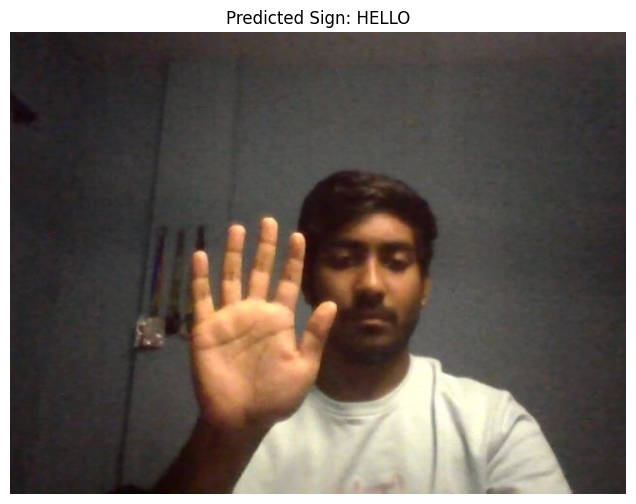


SIGN LANGUAGE PREDICTION
Predicted Sign: hello
Confidence: 91.00%
Image prediction completed! ✅


In [ ]:
# ============================================================
# TASK 4 - SIGN LANGUAGE IMAGE PREDICTION
# ============================================================

from google.colab import files
import cv2
import numpy as np
import mediapipe as mp
import joblib

# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------
model_path = "/content/drive/MyDrive/Internship_Datasets/TASK_4_Models/sign_language_model.pkl"

sign_model = joblib.load(model_path)

print("Sign language model loaded! ✅")


# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read the uploaded image.")


# ------------------------------------------------------------
# Convert image for MediaPipe
# ------------------------------------------------------------
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)


# ------------------------------------------------------------
# Detect hand
# ------------------------------------------------------------
result = hand_landmarker.detect(mp_image)


if not result.hand_landmarks:

    print("❌ No hand detected.")
    print("Please upload a clear image showing one hand.")

else:

    # --------------------------------------------------------
    # Extract 21 × 3 = 63 landmarks
    # --------------------------------------------------------
    landmarks = result.hand_landmarks[0]

    features = []

    for landmark in landmarks:
        features.extend([
            landmark.x,
            landmark.y,
            landmark.z
        ])

    features = np.array(
        features,
        dtype=np.float32
    ).reshape(1, -1)


    # --------------------------------------------------------
    # Predict sign
    # --------------------------------------------------------
    prediction = sign_model.predict(
        features
    )[0]

    predicted_sign = class_names[int(prediction)]


    # --------------------------------------------------------
    # Prediction confidence
    # --------------------------------------------------------
    probabilities = sign_model.predict_proba(
        features
    )[0]

    confidence = float(
        np.max(probabilities) * 100
    )


    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(
        f"Predicted Sign: {predicted_sign.upper()}"
    )
    plt.show()


    print("\n" + "=" * 50)
    print("SIGN LANGUAGE PREDICTION")
    print("=" * 50)

    print("Predicted Sign:", predicted_sign)
    print(f"Confidence: {confidence:.2f}%")

    print("=" * 50)
    print("Image prediction completed! ✅")

In [ ]:
# ============================================================
# TASK 4 - FINAL SIGN LANGUAGE GUI
# ============================================================

import gradio as gr
import cv2
import numpy as np
import joblib
from datetime import datetime
from zoneinfo import ZoneInfo


# ============================================================
# LOAD SAVED MODEL
# ============================================================

if "sign_model" not in globals():
    sign_model = joblib.load(
        "/content/drive/MyDrive/Internship_Datasets/TASK_4_Models/sign_language_model.pkl"
    )

print("Sign Language model loaded successfully! ✅")


# ============================================================
# SIGN CLASS NAMES
# ============================================================

class_names = [
    "ok",
    "i_love_you",
    "yes",
    "peace",
    "thank_you",
    "hello"
]


# ============================================================
# CHECK OPERATING HOURS
# ============================================================

def check_operating_hours():

    india_time = datetime.now(
        ZoneInfo("Asia/Kolkata")
    )

    hour = india_time.hour

    return 18 <= hour < 22


# ============================================================
# PREDICT SIGN FROM IMAGE
# ============================================================

def predict_sign(frame):

    if frame is None:
        return None, "Please provide an image."


    # --------------------------------------------------------
    # CHECK 6 PM - 10 PM
    # --------------------------------------------------------

    if not check_operating_hours():

        return (
            frame,
            "⏰ Detection is available only from 6:00 PM to 10:00 PM IST."
        )


    # --------------------------------------------------------
    # PREPARE IMAGE
    # --------------------------------------------------------

    image = np.asarray(frame)

    image = np.ascontiguousarray(image)


    # --------------------------------------------------------
    # MEDIAPIPE IMAGE
    # --------------------------------------------------------

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image
    )


    # --------------------------------------------------------
    # DETECT HAND
    # --------------------------------------------------------

    result = hand_landmarker.detect(mp_image)


    # --------------------------------------------------------
    # NO HAND
    # --------------------------------------------------------

    if not result.hand_landmarks:

        output = image.copy()

        cv2.putText(
            output,
            "No hand detected",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (255, 0, 0),
            2
        )

        return (
            output,
            "❌ No hand detected.\n\nPlease show your hand clearly."
        )


    # --------------------------------------------------------
    # EXTRACT HAND LANDMARKS
    # --------------------------------------------------------

    landmarks = result.hand_landmarks[0]

    features = []

    for landmark in landmarks:

        features.extend([
            landmark.x,
            landmark.y,
            landmark.z
        ])


    features = np.array(
        features,
        dtype=np.float32
    ).reshape(1, -1)


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    prediction = sign_model.predict(
        features
    )[0]

    probabilities = sign_model.predict_proba(
        features
    )[0]

    confidence = float(
        np.max(probabilities) * 100
    )


    # --------------------------------------------------------
    # GET SIGN NAME
    # --------------------------------------------------------

    predicted_sign = class_names[
        int(prediction)
    ]

    display_name = predicted_sign.replace(
        "_", " "
    ).upper()


    # --------------------------------------------------------
    # DRAW RESULT ON IMAGE
    # --------------------------------------------------------

    output = image.copy()

    cv2.rectangle(
        output,
        (10, 10),
        (output.shape[1] - 10, 90),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        output,
        display_name,
        (25, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        2
    )

    cv2.putText(
        output,
        f"Confidence: {confidence:.1f}%",
        (25, 78),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )


    # --------------------------------------------------------
    # RESULT TEXT
    # --------------------------------------------------------

    result_text = (
        f"🤟 Predicted Sign: {display_name}\n\n"
        f"📊 Confidence: {confidence:.2f}%\n\n"
        f"✅ Detection Successful"
    )

    return output, result_text


# ============================================================
# REAL-TIME VIDEO FUNCTION
# ============================================================

def process_video(frame):

    return predict_sign(frame)


# ============================================================
# FINAL GUI
# ============================================================

with gr.Blocks(
    title="Sign Language Detection"
) as task4_gui:

    gr.Markdown(
        """
# 🤟 Sign Language Detection

### Internship Task 4

This system recognizes sign-language words using
hand landmark detection and machine learning.

### Supported Signs

**OK • I LOVE YOU • YES • PEACE • THANK YOU • HELLO**

🕕 **Operational Time: 6:00 PM – 10:00 PM IST**
"""
    )


    # ========================================================
    # IMAGE UPLOAD SECTION
    # ========================================================

    gr.Markdown(
        """
## 🖼️ Upload Image

Upload an image containing a sign-language gesture
to identify the sign.
"""
    )

    with gr.Row():

        with gr.Column():

            image_input = gr.Image(
                sources=["upload"],
                type="numpy",
                label="Upload Sign Image"
            )

            image_predict_btn = gr.Button(
                "🔍 Predict Sign",
                variant="primary"
            )


        with gr.Column():

            image_output = gr.Image(
                type="numpy",
                label="Prediction Result"
            )

            image_result = gr.Textbox(
                label="Detection Result",
                lines=5,
                interactive=False
            )


    image_predict_btn.click(
        fn=predict_sign,
        inputs=image_input,
        outputs=[
            image_output,
            image_result
        ]
    )


    # ========================================================
    # REAL-TIME VIDEO SECTION
    # ========================================================

    gr.Markdown(
        """
## 🎥 Real-Time Video

Use your webcam to perform a sign-language gesture.
The system processes the live video and displays the prediction.
"""
    )

    with gr.Row():

        with gr.Column():

            webcam_input = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                label="🎥 Real-Time Webcam"
            )


        with gr.Column():

            webcam_output = gr.Image(
                type="numpy",
                label="🤟 Live Detection"
            )

            video_result = gr.Textbox(
                label="Live Detection Result",
                lines=5,
                interactive=False
            )


    webcam_input.stream(
        fn=process_video,
        inputs=webcam_input,
        outputs=[
            webcam_output,
            video_result
        ],
        stream_every=0.4,
        time_limit=300
    )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.Markdown(
        """
---

### 📌 System Features

- 🖼️ Upload Image Prediction
- 🎥 Real-Time Webcam Detection
- 🤟 Hand Landmark Detection
- 📊 Sign Classification
- 📈 Prediction Confidence
- 🕕 6 PM – 10 PM Operational Period
"""
    )


print("Task 4 GUI ready! ✅")
print("Includes image upload + real-time video.")
print("Operating hours: 6:00 PM – 10:00 PM IST")


task4_gui.launch(
    share=True,
    inline=True
)

Sign Language model loaded successfully! ✅
Task 4 GUI ready! ✅
Includes image upload + real-time video.
Operating hours: 6:00 PM – 10:00 PM IST
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca46be335b21b240ed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **TASK - 5 : Car Colour Detection Model**

***TO RUN GUI : CAR COLOUR DETECTION → MOUNT GOOGLE DRIVE →  LOAD SAVED CAR COLOUR MODEL (CPU SAFE) →  LOAD TRAFFIC DETECTION MODEL →  TRAFFIC IMAGE ANALYSIS PIPELINE → FINAL CAR COLOUR DETECTION GUI***

In [ ]:
# ============================================================
# TASK 5 - CAR COLOUR DETECTION
# ============================================================

!pip -q install ultralytics gradio

import cv2
import numpy as np
import gradio as gr
from ultralytics import YOLO
from PIL import Image

print("✅ Task 5 setup completed")
print("OpenCV version:", cv2.__version__)

✅ Task 5 setup completed
OpenCV version: 5.0.0


In [ ]:
# ============================================================
# TASK 5 - LOAD SAVED CAR COLOUR MODEL (CPU SAFE)
# ============================================================

import os

# Disable GPU for the GUI to avoid GPU memory conflicts/crashes
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import json

# ------------------------------------------------------------
# SAVED MODEL PATHS
# ------------------------------------------------------------

MODEL_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_5_Models/car_colour_classifier.keras"

CLASSES_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_5_Models/car_colour_classes.json"

# Same image size used during training

IMAGE_SIZE = (160, 160)

# ------------------------------------------------------------
# LOAD SAVED MODEL ON CPU
# ------------------------------------------------------------

with tf.device("/CPU:0"):

    saved_car_colour_model = tf.keras.models.load_model(
        MODEL_PATH
    )

# ------------------------------------------------------------
# LOAD CLASS NAMES
# ------------------------------------------------------------

with open(CLASSES_PATH, "r") as f:
    CLASS_NAMES = json.load(f)

print("✅ Saved car colour model loaded successfully!")
print("✅ Model loaded on CPU")
print("✅ Class names loaded successfully!")
print("🎨 Number of classes:", len(CLASS_NAMES))
print("🎨 Classes:", CLASS_NAMES)
print("📐 Image size:", IMAGE_SIZE)

✅ Saved car colour model loaded successfully!
✅ Model loaded on CPU
✅ Class names loaded successfully!
🎨 Number of classes: 15
🎨 Classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']
📐 Image size: (160, 160)


In [ ]:
# ============================================================
# TASK 5 - LOAD TRAFFIC DETECTION MODEL
# ============================================================

traffic_model = YOLO("yolo11n.pt")

TARGET_CLASSES = {"car", "person", "traffic light"}

print("✅ Traffic model loaded")
print("It will detect:", ", ".join(TARGET_CLASSES))

✅ Traffic model loaded
It will detect: traffic light, car, person


In [ ]:
# ============================================================
# TASK 5 - EXTRACT CAR COLOUR DATASET
# ============================================================

from pathlib import Path
import zipfile

DATASET_ZIP = Path(
    "/content/drive/MyDrive/Internship_Datasets/TASK_5_Dataset.zip"
)
DATASET_DIR = Path("/content/task5_car_colour_dataset")

if not DATASET_DIR.exists():
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print("✅ Dataset extracted successfully")
else:
    print("✅ Dataset is already extracted in this runtime")

print("Dataset folder:", DATASET_DIR)
print("Top-level contents:", [item.name for item in DATASET_DIR.iterdir()])

✅ Dataset extracted successfully
Dataset folder: /content/task5_car_colour_dataset
Top-level contents: ['val', 'test', 'train']


In [ ]:
# ============================================================
# TASK 5 - CHECK DATASET CLASSES AND IMAGE COUNTS
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

for split in ["train", "val", "test"]:
    split_path = DATASET_DIR / split
    colour_classes = sorted(
        folder.name for folder in split_path.iterdir() if folder.is_dir()
    )

    image_count = sum(
        1 for file in split_path.rglob("*")
        if file.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"\n{split.upper()} SET")
    print("Colour classes:", colour_classes)
    print("Number of images:", image_count)


TRAIN SET
Colour classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']
Number of images: 7267

VAL SET
Colour classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']
Number of images: 1550

TEST SET
Colour classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']
Number of images: 1556


In [ ]:
# ============================================================
# TASK 5 - PREPARE CAR COLOUR TRAINING DATA
# ============================================================

import tensorflow as tf

IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / "train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / "val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / "test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("✅ Data loaders are ready")
print("Number of colour classes:", len(CLASS_NAMES))
print("Classes:", CLASS_NAMES)

Found 7267 files belonging to 15 classes.
Found 1550 files belonging to 15 classes.
Found 1556 files belonging to 15 classes.
✅ Data loaders are ready
Number of colour classes: 15
Classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']


In [ ]:
# ============================================================
# TASK 5 - CREATE CAR COLOUR CNN MODEL
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
], name="data_augmentation")

car_colour_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMAGE_SIZE, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
], name="car_colour_classifier")

car_colour_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

car_colour_model.summary()

Model: "car_colour_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,247 (1.61 MB)

 Trainable params: 423,247 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# TASK 5 - TRAIN AND SAVE CAR COLOUR MODEL
# ============================================================

import json

MODEL_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_5_Models/car_colour_classifier.keras"

CLASSES_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_5_Models/car_colour_classes.json"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = car_colour_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

with open(CLASSES_PATH, "w") as file:
    json.dump(CLASS_NAMES, file)

print("✅ Training completed")
print("✅ Best model saved:", MODEL_PATH)
print("✅ Colour classes saved:", CLASSES_PATH)

Epoch 1/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2716 - loss: 2.1909
Epoch 1: val_accuracy improved from None to 0.39355, saving model to /content/drive/MyDrive/Task5_Car_Colour/car_colour_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Task5_Car_Colour/car_colour_classifier.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.3936 - loss: 1.7871 - val_accuracy: 0.3935 - val_loss: 2.0083 - learning_rate: 5.0000e-04
Epoch 2/15
226/228 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5140 - loss: 1.3939
Epoch 2: val_accuracy improved from 0.39355 to 0.57032, saving model to /content/drive/MyDrive/Task5_Car_Colour/car_colour_classifier.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Task5_Car_Colour/car_colour_classifier.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.5368 - loss: 1.3210 - val_accuracy: 0.5703 - val_loss: 1.2337 - learning_rate: 5.0000e-04
Epoch 3/15
226/228 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/s

In [ ]:
# ============================================================
# TASK 5 - TEST SAVED CAR COLOUR MODEL
# ============================================================

saved_car_colour_model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_accuracy = saved_car_colour_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\n✅ Test accuracy: {test_accuracy * 100:.2f}%")
print(f"✅ Test loss: {test_loss:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7371 - loss: 0.7251

✅ Test accuracy: 73.71%
✅ Test loss: 0.7251


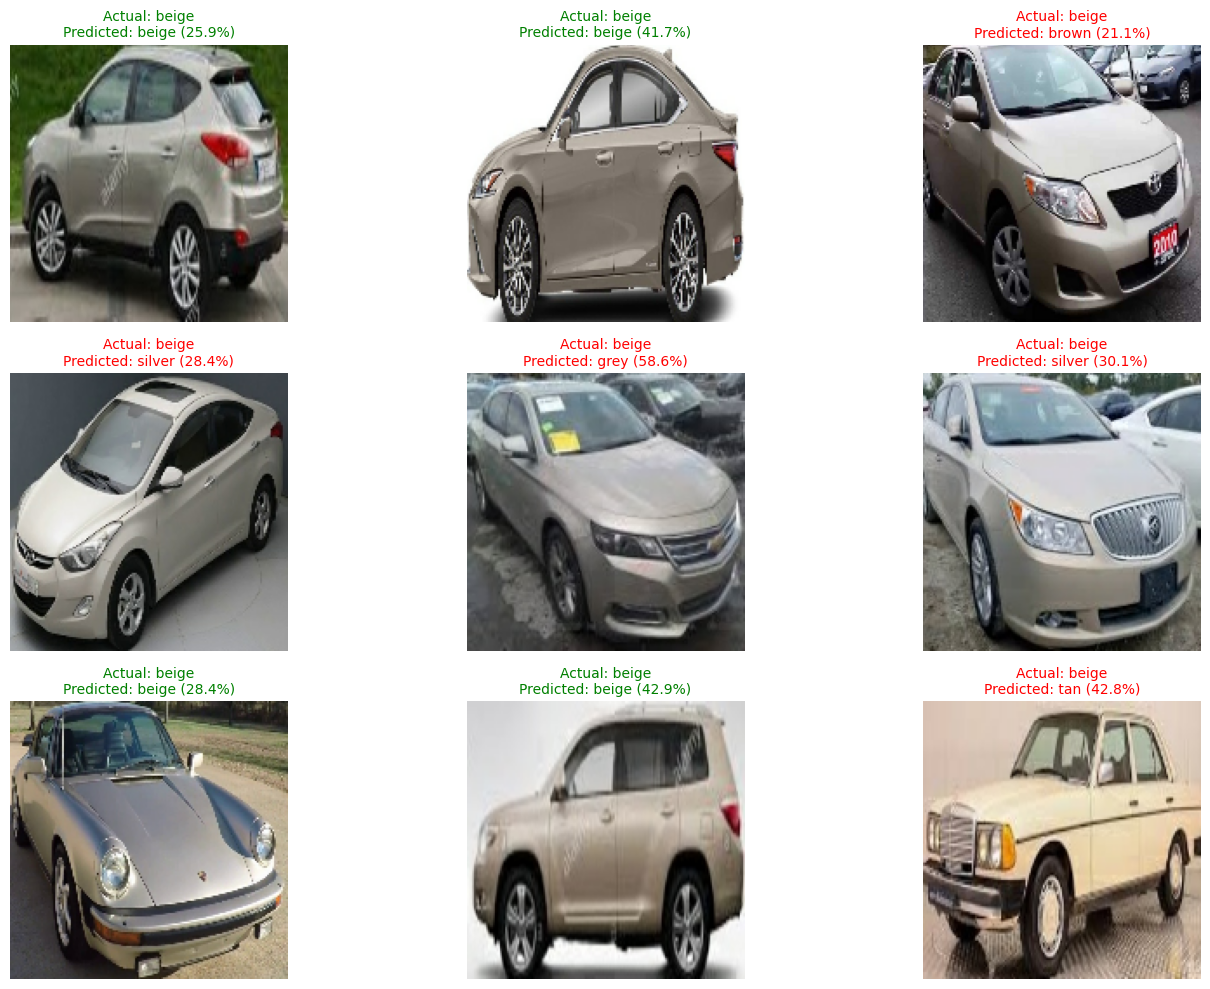

In [ ]:
# ============================================================
# TASK 5 - PREVIEW CAR COLOUR PREDICTIONS
# ============================================================

import matplotlib.pyplot as plt

images, true_labels = next(iter(test_ds.take(1)))

probabilities = saved_car_colour_model.predict(images, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
confidences = np.max(probabilities, axis=1) * 100

plt.figure(figsize=(15, 10))

for index in range(min(9, len(images))):
    plt.subplot(3, 3, index + 1)
    plt.imshow(images[index].numpy().astype("uint8"))
    plt.axis("off")

    actual_colour = CLASS_NAMES[true_labels[index].numpy()]
    predicted_colour = CLASS_NAMES[predicted_labels[index]]

    plt.title(
        f"Actual: {actual_colour}\n"
        f"Predicted: {predicted_colour} ({confidences[index]:.1f}%)",
        color="green" if actual_colour == predicted_colour else "red",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 5 - TRAFFIC IMAGE ANALYSIS PIPELINE
# ============================================================

def analyse_traffic_image(image_rgb):
    """
    Detect cars, people and traffic lights.

    Required rules:
    - Blue cars  -> RED rectangles
    - Other cars -> BLUE rectangles
    - People are counted only near the detected traffic signal
    """

    if image_rgb is None:
        return None, {
            "Cars detected": 0,
            "Blue cars (red boxes)": 0,
            "Other-colour cars (blue boxes)": 0,
            "People at traffic signal": 0,
            "Traffic lights detected": 0
        }

    output_bgr = cv2.cvtColor(
        image_rgb.copy(),
        cv2.COLOR_RGB2BGR
    )

    # --------------------------------------------------------
    # YOLO DETECTION
    # --------------------------------------------------------

    detections = traffic_model(
        image_rgb,
        conf=0.30,
        verbose=False
    )[0]

    cars = []
    people = []
    traffic_lights = []

    for box in detections.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        object_name = detections.names[class_id]

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].tolist()
        )

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(image_rgb.shape[1], x2)
        y2 = min(image_rgb.shape[0], y2)

        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2

        info = {
            "box": (x1, y1, x2, y2),
            "center": (center_x, center_y),
            "confidence": confidence
        }

        if object_name == "car":
            cars.append(info)

        elif object_name == "person":
            people.append(info)

        elif object_name == "traffic light":
            traffic_lights.append(info)

    # --------------------------------------------------------
    # TRAFFIC SIGNAL ZONE
    # --------------------------------------------------------
    # Used internally to determine whether a person is
    # near the traffic signal.
    # The zone itself is NOT drawn on the final image.

    signal_zones = []

    image_height, image_width = image_rgb.shape[:2]

    for light in traffic_lights:

        x1, y1, x2, y2 = light["box"]

        light_width = max(1, x2 - x1)
        light_height = max(1, y2 - y1)

        zone_x1 = max(
            0,
            x1 - int(light_width * 4)
        )

        zone_x2 = min(
            image_width,
            x2 + int(light_width * 4)
        )

        zone_y1 = y2

        zone_y2 = min(
            image_height,
            y2 + int(light_height * 12)
        )

        signal_zones.append(
            (zone_x1, zone_y1, zone_x2, zone_y2)
        )

    # --------------------------------------------------------
    # COUNT PEOPLE AT TRAFFIC SIGNAL
    # --------------------------------------------------------

    people_at_signal = []

    for person in people:

        px, py = person["center"]

        at_signal = False

        for zone_x1, zone_y1, zone_x2, zone_y2 in signal_zones:

            if (
                zone_x1 <= px <= zone_x2
                and
                zone_y1 <= py <= zone_y2
            ):
                at_signal = True
                break

        if at_signal:

            people_at_signal.append(person)

            x1, y1, x2, y2 = person["box"]

            cv2.rectangle(
                output_bgr,
                (x1, y1),
                (x2, y2),
                (0, 180, 0),
                2
            )

            cv2.putText(
                output_bgr,
                "Person at Signal",
                (x1, max(25, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (0, 180, 0),
                2
            )

    # --------------------------------------------------------
    # DRAW TRAFFIC LIGHTS
    # --------------------------------------------------------

    for light in traffic_lights:

        x1, y1, x2, y2 = light["box"]

        cv2.rectangle(
            output_bgr,
            (x1, y1),
            (x2, y2),
            (0, 165, 255),
            2
        )

        cv2.putText(
            output_bgr,
            "Traffic Light",
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 165, 255),
            2
        )

    # --------------------------------------------------------
    # CAR COLOUR PREDICTION
    # --------------------------------------------------------

    car_count = 0

    blue_car_count = 0

    for car in cars:

        x1, y1, x2, y2 = car["box"]

        car_crop = image_rgb[y1:y2, x1:x2]

        if car_crop.size == 0:
            continue

        resized_car = cv2.resize(
            car_crop,
            IMAGE_SIZE
        )

        prediction = saved_car_colour_model.predict(
            np.expand_dims(resized_car, axis=0),
            verbose=0
        )[0]

        colour_index = int(
            np.argmax(prediction)
        )

        car_colour = CLASS_NAMES[colour_index]

        colour_confidence = float(
            prediction[colour_index] * 100
        )

        car_count += 1

        # ----------------------------------------------------
        # REQUIRED RECTANGLE RULE
        # ----------------------------------------------------

        if car_colour.lower() == "blue":

            # RED rectangle for BLUE car
            rectangle_colour = (0, 0, 255)
            blue_car_count += 1

        else:

            # BLUE rectangle for all other cars
            rectangle_colour = (255, 0, 0)

        label = (
            f"Car: {car_colour} "
            f"({colour_confidence:.0f}%)"
        )

        cv2.rectangle(
            output_bgr,
            (x1, y1),
            (x2, y2),
            rectangle_colour,
            3
        )

        cv2.putText(
            output_bgr,
            label,
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            rectangle_colour,
            2
        )

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    summary = {
        "Cars detected": car_count,
        "Blue cars (red boxes)": blue_car_count,
        "Other-colour cars (blue boxes)":
            car_count - blue_car_count,
        "People at traffic signal":
            len(people_at_signal),
        "Traffic lights detected":
            len(traffic_lights)
    }

    # RGB output for Gradio
    output_rgb = cv2.cvtColor(
        output_bgr,
        cv2.COLOR_BGR2RGB
    )

    return output_rgb, summary


print("✅ Traffic-analysis pipeline is ready")

✅ Traffic-analysis pipeline is ready


In [ ]:
# ============================================================
# TASK 5 - FINAL CAR COLOUR DETECTION GUI
# ============================================================

import gradio as gr
import cv2
import numpy as np

def run_task5_gui(image):

    if image is None:
        return (
            None,
            None,
            "## ⚠️ No Image Uploaded\n\nPlease upload a traffic image first."
        )

    # Run existing traffic analysis pipeline
    annotated_image, summary = analyse_traffic_image(image)

    result_text = f"""
# 🚦 Traffic Analysis Result

### 🚗 Vehicle Detection
- **Cars detected:** `{summary["Cars detected"]}`
- **🔴 Blue cars:** `{summary["Blue cars (red boxes)"]}`
- **🔵 Other-colour cars:** `{summary["Other-colour cars (blue boxes)"]}`

### 🚶 Traffic Signal Analysis
- **People at traffic signal:** `{summary["People at traffic signal"]}`
- **🚦 Traffic lights detected:** `{summary["Traffic lights detected"]}`

---

### 🎨 Detection Legend

🔴 **Red rectangle** → Blue car

🔵 **Blue rectangle** → Other-colour car

🟠 **Orange label** → Traffic light
"""

    return image, annotated_image, result_text


# ============================================================
# FINAL GUI
# ============================================================

with gr.Blocks(
    title="Task 5 - Car Colour Detection",
    theme=gr.themes.Soft()
) as task5_gui:

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.Markdown(
        """
# 🚗 Car Colour Detection at Traffic Signals

### AI-Based Traffic Image Analysis System

Upload a traffic image and the system will:

**Detect Cars → Predict Car Colour → Detect Traffic Lights → Count People Near Signals**

---

### 🎯 Supported Analysis

🚗 **Car Detection**
🎨 **Car Colour Classification**
🚦 **Traffic Light Detection**
🚶 **People Near Traffic Signal**
"""
    )


    # --------------------------------------------------------
    # IMAGE INPUT
    # --------------------------------------------------------

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown(
                """
### 📤 Step 1 — Upload Traffic Image

Upload a clear image containing vehicles and,
if possible, a traffic signal.
"""
            )

            traffic_image_input = gr.Image(
                label="📷 Traffic Image",
                type="numpy",
                sources=["upload"]
            )

            analyse_button = gr.Button(
                "🔍 Analyse Traffic Image",
                variant="primary",
                size="lg"
            )

            clear_button = gr.ClearButton(
                components=[
                    traffic_image_input
                ],
                value="🗑️ Clear Image"
            )


        # ----------------------------------------------------
        # INPUT PREVIEW
        # ----------------------------------------------------

        with gr.Column(scale=1):

            gr.Markdown(
                """
### 🖼️ Step 2 — Input Preview

The uploaded image will appear here.
"""
            )

            input_preview = gr.Image(
                label="Original Traffic Image",
                type="numpy"
            )


    # --------------------------------------------------------
    # DETECTION RESULT
    # --------------------------------------------------------

    gr.Markdown(
        """
## 🔎 Detection Output
"""
    )

    with gr.Row():

        with gr.Column(scale=1):

            annotated_output = gr.Image(
                label="🤖 AI Detection Result",
                type="numpy"
            )


        with gr.Column(scale=1):

            result_output = gr.Markdown(
                value="""
## 📊 Analysis Result

Upload an image and click **Analyse Traffic Image**.
"""
            )


    # --------------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------------

    analyse_button.click(
        fn=run_task5_gui,
        inputs=traffic_image_input,
        outputs=[
            input_preview,
            annotated_output,
            result_output
        ]
    )


    # --------------------------------------------------------
    # INFORMATION SECTION
    # --------------------------------------------------------

    gr.Markdown(
        """
---

## 📌 How It Works

**Traffic Image**
→ **YOLO Object Detection**
→ **Car Detection**
→ **Car Colour CNN**
→ **Traffic Light Detection**
→ **People Near Signal**
→ **Annotated Result + Summary**

### 🎨 Rectangle Rules

🔴 **Red Box = Blue Car**

🔵 **Blue Box = Other Colour Car**

🟠 **Orange Label = Traffic Light**

---

### ✅ Task 5 Features

- 🚗 Car detection
- 🎨 Car colour classification
- 🚦 Traffic light detection
- 🚶 People counting near traffic signals
- 📊 Detection summary
- 🖼️ Original image preview
- 🤖 Annotated AI output
"""
    )


# ============================================================
# LAUNCH GUI
# ============================================================

print("Task 5 improved GUI ready! ✅")

task5_gui.launch(
    share=True,
    inline=True
)

Task 5 improved GUI ready! ✅
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ed07991dc953a4284.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ***TASK - 6 : Nationality Detection Model***

***TO RUN GUI : TASK 6 - LOAD REQUIRED MODELS → TASK 6 - LOAD SAVED EMOTION MODEL → TASK 6 - LOAD SAVED DRESS COLOUR MODEL → TASK 6 - OPENCV SETUP → TASK 6 - IMPROVED COMBINED PREDICTION PIPELINE → TASK 6 - FINAL GUI***

In [ ]:
# ============================================================
# TASK 6 - NATIONALITY DETECTION MODEL
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

print("Task 6 libraries loaded successfully! ✅")
print("TensorFlow version:", tf.__version__)

Task 6 libraries loaded successfully! ✅
TensorFlow version: 2.21.0


In [ ]:
# ============================================================
# TASK 6 - LOAD REQUIRED MODELS
# ============================================================

from google.colab import drive
import os

drive.mount("/content/drive")

# Load existing Age + Gender model
AGE_GENDER_MODEL_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_1_Models/best_model.keras"

model = tf.keras.models.load_model(
    AGE_GENDER_MODEL_PATH
)

print("Age-Gender model loaded successfully! ✅")
print("Model path:", AGE_GENDER_MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Age-Gender model loaded successfully! ✅
Model path: /content/drive/MyDrive/best_model.keras


In [ ]:
# ============================================================
# TASK 6 - EMOTION DATASET SETUP
# ============================================================

!pip -q install kagglehub

import kagglehub
import os

print("Downloading emotion dataset...")

emotion_dataset_path = kagglehub.dataset_download(
    "msambare/fer2013"
)

print("Emotion dataset downloaded successfully! ✅")
print("Dataset path:", emotion_dataset_path)

Using Colab cache for faster access to the 'fer2013' dataset.
Emotion dataset downloaded successfully! ✅
Dataset path: /kaggle/input/fer2013


In [ ]:
# ============================================================
# TASK 6 - CHECK EMOTION DATASET STRUCTURE
# ============================================================

import os

print("Checking downloaded emotion dataset...")

dataset_root = emotion_dataset_path

# Show folders and files inside the dataset
for root, dirs, files_list in os.walk(dataset_root):

    level = root.replace(dataset_root, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files_list[:10]:
        print(f"{indent}  {file}")

print("\n✅ Emotion dataset structure checked!")

Checking downloaded emotion dataset...
fer2013/
  test/
    surprise/
      PublicTest_78686873.jpg
      PrivateTest_58522921.jpg
      PrivateTest_83796714.jpg
      PublicTest_84428313.jpg
      PrivateTest_87978901.jpg
      PrivateTest_90978621.jpg
      PrivateTest_27580582.jpg
      PublicTest_15760011.jpg
      PublicTest_49739228.jpg
      PublicTest_5351857.jpg
    fear/
      PublicTest_67261410.jpg
      PrivateTest_80486885.jpg
      PrivateTest_29930852.jpg
      PublicTest_61256129.jpg
      PrivateTest_86063456.jpg
      PublicTest_24599099.jpg
      PrivateTest_87242310.jpg
      PublicTest_61582364.jpg
      PublicTest_18140182.jpg
      PrivateTest_20960444.jpg
    angry/
      PublicTest_3641536.jpg
      PublicTest_21334851.jpg
      PrivateTest_56252993.jpg
      PrivateTest_46881419.jpg
      PrivateTest_88795628.jpg
      PrivateTest_29624948.jpg
      PrivateTest_15827448.jpg
      PrivateTest_22793925.jpg
      PublicTest_66091352.jpg
      PrivateTest_4606706

In [ ]:
# ============================================================
# TASK 6 - PREPARE EMOTION TRAINING DATA
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (48, 48)
BATCH_SIZE = 64

# Find the directory containing the emotion class folders
emotion_root = emotion_dataset_path

# If there is a nested directory containing the class folders,
# locate it automatically.
emotion_classes = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

for root, dirs, files_list in os.walk(emotion_dataset_path):
    if all(cls in dirs for cls in emotion_classes):
        emotion_root = root
        break

print("Emotion dataset root:", emotion_root)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20
)

# Training data
emotion_train_generator = train_datagen.flow_from_directory(
    emotion_root,
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    subset="training",
    shuffle=True,
    seed=42
)

# Validation data
emotion_val_generator = train_datagen.flow_from_directory(
    emotion_root,
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False,
    seed=42
)

print("\n✅ Emotion training data prepared!")
print("Classes:", emotion_train_generator.class_indices)
print("Training images:", emotion_train_generator.samples)
print("Validation images:", emotion_val_generator.samples)

Emotion dataset root: /kaggle/input/fer2013/test
Found 5746 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.

✅ Emotion training data prepared!
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training images: 5746
Validation images: 1432


In [ ]:
# ============================================================
# TASK 6 - CREATE EMOTION CNN MODEL
# ============================================================

from tensorflow.keras import layers, models

emotion_model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(7, activation="softmax")
])

emotion_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

emotion_model.summary()

print("✅ Emotion CNN model created successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

✅ Emotion CNN model created successfully!


In [ ]:
# ============================================================
# TASK 6 - TRAIN EMOTION CNN MODEL
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EMOTION_MODEL_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_6_Models/task6_emotion_model.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    EMOTION_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

history_emotion = emotion_model.fit(
    emotion_train_generator,
    validation_data=emotion_val_generator,
    epochs=30,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("\n✅ Emotion CNN training completed!")
print("Best model saved to:")
print(EMOTION_MODEL_PATH)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.2065 - loss: 1.8627
Epoch 1: val_accuracy improved from None to 0.24930, saving model to /content/drive/MyDrive/task6_emotion_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/task6_emotion_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 55s 584ms/step - accuracy: 0.2229 - loss: 1.8427 - val_accuracy: 0.2493 - val_loss: 1.8120
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.2493 - loss: 1.8149
Epoch 2: val_accuracy improved from 0.24930 to 0.25628, saving model to /content/drive/MyDrive/task6_emotion_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/task6_emotion_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 370ms/step - accuracy: 0.2450 - loss: 1.8106 - val_accuracy: 0.2563 - val_loss: 1.7846
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.2539 - loss: 1.7824
Epoch 3: val_accuracy improved from 0.25628 to 0.26746, saving model to /content/drive/MyDrive/task

In [ ]:
# ============================================================
# TASK 6 - EVALUATE EMOTION MODEL
# ============================================================

# Load the best saved model
emotion_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/task6_emotion_model.keras"
)

# Evaluate on validation data
val_loss, val_accuracy = emotion_model.evaluate(
    emotion_val_generator,
    verbose=1
)

print("\n========================================")
print("EMOTION MODEL EVALUATION")
print("========================================")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")

print("\n✅ Emotion CNN evaluation completed successfully!")

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 468ms/step - accuracy: 0.4825 - loss: 1.3532

EMOTION MODEL EVALUATION
Validation Loss     : 1.3532
Validation Accuracy : 0.4825
Validation Accuracy : 48.25%

✅ Emotion CNN evaluation completed successfully!


In [ ]:
# TASK 6 - LOAD SAVED EMOTION MODEL

EMOTION_MODEL_PATH = "/content/drive/MyDrive/task6_emotion_model.keras"

emotion_model = tf.keras.models.load_model(
    EMOTION_MODEL_PATH
)

print("✅ Emotion model loaded successfully!")

✅ Emotion model loaded successfully!


In [ ]:
# ============================================================
# TASK 6 - LOAD DRESS COLOUR DATASET FROM GOOGLE DRIVE
# ============================================================

import os
import zipfile
import shutil

DRESS_ZIP_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_6_Dataset.zip"
dress_dataset_root = "/content/task6_dress_dataset"

if not os.path.exists(DRESS_ZIP_PATH):
    raise FileNotFoundError(
        f"Dress colour dataset not found:\n{DRESS_ZIP_PATH}"
    )

if os.path.exists(dress_dataset_root):
    shutil.rmtree(dress_dataset_root)

os.makedirs(dress_dataset_root, exist_ok=True)

with zipfile.ZipFile(DRESS_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(dress_dataset_root)

print("✅ Dress colour dataset extracted successfully!")
print("Dataset location:", dress_dataset_root)

✅ Dress colour dataset extracted successfully!
Dataset location: /content/task6_dress_dataset


In [ ]:
# TASK 6 - CHECK DRESS DATASET STRUCTURE

import os
for root, dirs, files_list in os.walk(dress_dataset_root):
    level = root.replace(dress_dataset_root, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files_list[:5]:
            print(f"{indent}  {file}")

print("\n✅ Dress dataset structure checked!")

task6_dress_dataset/
  black_suit/
    000286.jpg
    000287.jpg
    000033.jpg
    000289.jpg
    000326.jpg
  black_shirt/
    186.jpg
    597.jpg
    715.jpg
    238.jpg
    530.jpg
  green_shoes/
    186.jpg
    238.jpg
    111.jpg
    307.jpg
    299.jpg
  white_shorts/
    111.jpg
    19.jpg
    7.jpg
    51.jpg
    63.jpg
  silver_shoes/
    000286.jpg
    000379.jpg
    000287.jpg
    000325.jpg
    000423.jpg
  green_shorts/
    111.jpg
    19.jpg
    7.jpg
    128.jpg
    51.jpg
  blue_dress/
    186.jpg
    238.jpg
    111.jpg
    307.jpg
    299.jpg
  brown_pants/
    186.jpg
    238.jpg
    111.jpg
    307.jpg
    299.jpg
  yellow_dress/
    000379.jpg
    000287.jpg
    000509.jpg
    000325.jpg
    000423.jpg
  brown_hoodie/
    000286.jpg
    000033.jpg
    000326.jpg
    000409.jpg
    000064.jpg
  green_suit/
    000286.jpg
    000033.jpg
    000289.jpg
    000064.jpg
    000291.jpg
  black_shoes/
    186.jpg
    760.jpg
    597.jpg
    715.jpg
    238.jpg
  yellow_sh

In [ ]:
# TASK 6 - FIND DRESS COLOUR CLASSES

import os

image_extensions = (".jpg", ".jpeg", ".png", ".webp")
dress_classes = {}

for root, dirs, files_list in os.walk(dress_dataset_root):
    image_files = [
        f for f in files_list
        if f.lower().endswith(image_extensions)
    ]

    if image_files and "dress" in os.path.basename(root).lower():
        class_name = os.path.basename(root)
        dress_classes[class_name] = len(image_files)

print("Dress classes found:\n")

for cls, count in sorted(dress_classes.items()):
    print(f"{cls}: {count} images")

print(f"\nTotal dress classes: {len(dress_classes)}")
print("✅ Dress class detection completed!")

Dress classes found:

black_dress: 450 images
blue_dress: 502 images
red_dress: 800 images
white_dress: 818 images
yellow_dress: 566 images

Total dress classes: 5
✅ Dress class detection completed!


In [ ]:
# TASK 6 - PREPARE ONLY DRESS COLOUR DATA

import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DRESS_IMAGE_SIZE = (128, 128)
DRESS_BATCH_SIZE = 32

# Only these 5 dress classes
selected_dress_classes = [
    "black_dress",
    "blue_dress",
    "red_dress",
    "white_dress",
    "yellow_dress"
]

# Create clean dataset folder
dress_only_root = "/content/task6_dress_only"

if os.path.exists(dress_only_root):
    shutil.rmtree(dress_only_root)

os.makedirs(dress_only_root, exist_ok=True)

# Copy only the required dress folders
for class_name in selected_dress_classes:

    source = os.path.join(
        dress_dataset_root,
        class_name
    )

    destination = os.path.join(
        dress_only_root,
        class_name
    )

    shutil.copytree(
        source,
        destination
    )

print("Selected dress classes:")

for cls in selected_dress_classes:

    count = len(
        os.listdir(
            os.path.join(
                dress_only_root,
                cls
            )
        )
    )

    print(f"{cls}: {count} images")


# -----------------------------
# TRAINING DATA
# -----------------------------

dress_train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.20
)


# -----------------------------
# VALIDATION DATA
# No augmentation
# -----------------------------

dress_val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.20
)


# -----------------------------
# TRAINING GENERATOR
# -----------------------------

dress_train_generator = dress_train_datagen.flow_from_directory(
    dress_only_root,
    target_size=DRESS_IMAGE_SIZE,
    batch_size=DRESS_BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)


# -----------------------------
# VALIDATION GENERATOR
# -----------------------------

dress_val_generator = dress_val_datagen.flow_from_directory(
    dress_only_root,
    target_size=DRESS_IMAGE_SIZE,
    batch_size=DRESS_BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)


print("\nClass indices:")
print(dress_train_generator.class_indices)

print("\nTraining images:", dress_train_generator.samples)
print("Validation images:", dress_val_generator.samples)

print("\n✅ Only dress-colour data prepared successfully!")

Selected dress classes:
black_dress: 450 images
blue_dress: 502 images
red_dress: 800 images
white_dress: 818 images
yellow_dress: 566 images
Found 2510 images belonging to 5 classes.
Found 626 images belonging to 5 classes.

Class indices:
{'black_dress': 0, 'blue_dress': 1, 'red_dress': 2, 'white_dress': 3, 'yellow_dress': 4}

Training images: 2510
Validation images: 626

✅ Only dress-colour data prepared successfully!


In [ ]:
# TASK 6 - CREATE DRESS COLOUR CNN MODEL

from tensorflow.keras import layers, models

dress_colour_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(5, activation="softmax")
])

dress_colour_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dress_colour_model.summary()

print("✅ Dress colour CNN model created successfully!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

✅ Dress colour CNN model created successfully!


In [ ]:
# TASK 6 - TRAIN DRESS COLOUR CNN MODEL

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DRESS_MODEL_PATH = "/content/drive/MyDrive/Internship_Datasets/TASK_6_Models/task6_dress_colour_model.keras"

early_stopping_dress = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_dress = ModelCheckpoint(
    DRESS_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

history_dress = dress_colour_model.fit(
    dress_train_generator,
    validation_data=dress_val_generator,
    epochs=10,
    callbacks=[early_stopping_dress, checkpoint_dress],
    verbose=1
)

print("\n✅ Dress colour CNN training completed!")
print("Best model saved to:")
print(DRESS_MODEL_PATH)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9763 - loss: 0.0979
Epoch 1: val_accuracy improved from None to 0.97125, saving model to /content/drive/MyDrive/task6_dress_colour_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/task6_dress_colour_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9741 - loss: 0.1006 - val_accuracy: 0.9712 - val_loss: 0.1044
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9761 - loss: 0.0892
Epoch 2: val_accuracy did not improve from 0.97125
79/79 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9741 - loss: 0.0976 - val_accuracy: 0.9712 - val_loss: 0.0769
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9693 - loss: 0.1028
Epoch 3: val_accuracy improved from 0.97125 to 0.99042, saving model to /content/drive/MyDrive/task6_dress_colour_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/task6_dress_colour_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step -

In [ ]:
# TASK 6 - EVALUATE DRESS COLOUR MODEL

dress_colour_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/task6_dress_colour_model.keras"
)

dress_val_loss, dress_val_accuracy = dress_colour_model.evaluate(
    dress_val_generator,
    verbose=1
)

print("\n📊 Dress Colour Model Performance")
print(f"Validation Loss: {dress_val_loss:.4f}")
print(f"Validation Accuracy: {dress_val_accuracy * 100:.2f}%")

print("\n✅ Dress colour model evaluation completed!")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.9920 - loss: 0.0293

📊 Dress Colour Model Performance
Validation Loss: 0.0293
Validation Accuracy: 99.20%

✅ Dress colour model evaluation completed!


In [ ]:
# TASK 6 - LOAD SAVED DRESS COLOUR MODEL

DRESS_MODEL_PATH = "/content/drive/MyDrive/task6_dress_colour_model.keras"

dress_colour_model = tf.keras.models.load_model(
    DRESS_MODEL_PATH
)

print("✅ Dress colour model loaded successfully!")

✅ Dress colour model loaded successfully!


In [ ]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install -q --no-deps opencv-python==4.11.0.86

print("✅ OpenCV 4.11.0.86 installation completed.")
print("⚠️ NOW RESTART THE RUNTIME.")

Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
✅ OpenCV 4.11.0.86 installation completed.
⚠️ NOW RESTART THE RUNTIME.


In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:", hasattr(cv2, "CascadeClassifier"))

OpenCV version: 4.11.0
CascadeClassifier available: True


In [ ]:
# ============================================================
# TASK 6 - OPENCV SETUP
# ============================================================

import cv2

print("OpenCV version:", cv2.__version__)

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_detector.empty():
    raise RuntimeError("❌ Face detector could not be loaded.")

print("✅ OpenCV is ready for Task 6.")
print("✅ Face detector loaded successfully.")

OpenCV version: 4.11.0
✅ OpenCV is ready for Task 6.
✅ Face detector loaded successfully.


In [ ]:
# TASK 6 - IMPROVED COMBINED PREDICTION PIPELINE

import cv2
import numpy as np

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad",
    6: "Surprise"
}

dress_labels = {
    0: "Black",
    1: "Blue",
    2: "Red",
    3: "White",
    4: "Yellow"
}


def get_face_crop(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return image

    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    margin = int(0.15 * max(w, h))

    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(image.shape[1], x + w + margin)
    y2 = min(image.shape[0], y + h + margin)

    return image[y1:y2, x1:x2]


def predict_age(image):

    # Detect the face
    gray_full = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray_full,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    # If no face is detected, use the complete image
    if len(faces) == 0:
        face = image
    else:
        # Select the largest detected face
        x, y, w, h = max(
            faces,
            key=lambda f: f[2] * f[3]
        )

        # Larger margin around the face
        margin = int(0.15 * max(w, h))

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(image.shape[1], x + w + margin)
        y2 = min(image.shape[0], y + h + margin)

        face = image[y1:y2, x1:x2]

    # Convert to grayscale
    gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    # Resize exactly as required by the trained model
    gray = cv2.resize(
        gray,
        (128, 128)
    )

    # Normalize
    arr = gray.astype("float32") / 255.0

    # Add batch + channel dimensions
    arr = arr.reshape(
        1, 128, 128, 1
    )

    # Predict
    prediction = model.predict(
        arr,
        verbose=0
    )

    age = float(
        prediction[1][0][0]
    )

    return age

def predict_emotion(image):

    face = get_face_crop(image)

    gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (48, 48))

    arr = gray.astype("float32") / 255.0
    arr = arr.reshape(1, 48, 48, 1)

    prediction = emotion_model.predict(arr, verbose=0)

    index = int(np.argmax(prediction[0]))

    return emotion_labels[index]

# ============================================================
# TASK 6 - DRESS COLOUR PREDICTION - FINAL FIX
# ============================================================

import cv2
import numpy as np


def predict_dress_colour(image):

    h, w = image.shape[:2]

    # --------------------------------------------------------
    # 1. Focus tightly on the central torso
    # --------------------------------------------------------
    # This avoids roads, trees, buildings and other background.
    y1 = int(h * 0.42)
    y2 = int(h * 0.88)

    x1 = int(w * 0.32)
    x2 = int(w * 0.68)

    torso = image[y1:y2, x1:x2]

    if torso.size == 0:
        torso = image

    # --------------------------------------------------------
    # 2. Convert to HSV
    # --------------------------------------------------------
    hsv = cv2.cvtColor(torso, cv2.COLOR_BGR2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # --------------------------------------------------------
    # 3. Colour masks
    # --------------------------------------------------------

    blue = (
        (H >= 90) &
        (H <= 140) &
        (S >= 50) &
        (V >= 25)
    )

    yellow = (
        (H >= 15) &
        (H <= 40) &
        (S >= 70) &
        (V >= 60)
    )

    red = (
        (
            (H <= 10) |
            (H >= 170)
        ) &
        (S >= 70) &
        (V >= 50)
    )

    # White = bright + very low saturation
    white = (
        (S <= 35) &
        (V >= 190)
    )

    # Black/dark
    black = (
        (V <= 55)
    )

    # --------------------------------------------------------
    # 4. Calculate colour percentages
    # --------------------------------------------------------

    total = H.size

    ratios = {
        "Blue": np.sum(blue) / total,
        "Yellow": np.sum(yellow) / total,
        "Red": np.sum(red) / total,
        "White": np.sum(white) / total,
        "Black": np.sum(black) / total
    }

    print("👗 Dress colour analysis:")

    for colour, ratio in ratios.items():
        print(f"{colour}: {ratio * 100:.2f}%")

    # --------------------------------------------------------
    # 5. Ignore tiny colour regions
    # --------------------------------------------------------

    significant_colours = {
        colour: ratio
        for colour, ratio in ratios.items()
        if ratio >= 0.05
    }

    # --------------------------------------------------------
    # 6. Prefer the dominant clothing colour
    # --------------------------------------------------------

    if significant_colours:

        predicted_colour = max(
            significant_colours,
            key=significant_colours.get
        )

        return predicted_colour

    # --------------------------------------------------------
    # 7. CNN fallback
    # --------------------------------------------------------

    dress_region = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2RGB
    )

    dress_region = cv2.resize(
        dress_region,
        (128, 128)
    )

    arr = dress_region.astype("float32") / 255.0

    arr = arr.reshape(
        1, 128, 128, 3
    )

    prediction = dress_colour_model.predict(
        arr,
        verbose=0
    )

    index = int(
        np.argmax(prediction[0])
    )

    return dress_labels[index]

def task6_prediction(image, nationality):

    result = {
        "Nationality": nationality,
        "Emotion": predict_emotion(image)
    }

    if nationality == "Indian":

        result["Age"] = round(
            predict_age(image), 2
        )

        result["Dress Colour"] = (
            predict_dress_colour(image)
        )

    elif nationality == "United States":

        result["Age"] = round(
            predict_age(image), 2
        )

    elif nationality == "African":

        result["Dress Colour"] = (
            predict_dress_colour(image)
        )

    return result


print("✅ Improved Task 6 prediction pipeline created successfully!")

✅ Improved Task 6 prediction pipeline created successfully!


In [ ]:
# ============================================================
# TASK 6 - FINAL GUI
# NATIONALITY + AGE + EMOTION + DRESS COLOUR
# ============================================================

import gradio as gr
import cv2


def run_task6_gui(image, nationality):

    # Check image
    if image is None:
        return None, "### ⚠️ Please upload a person's image first."

    # Check nationality
    if nationality is None:
        return image, "### ⚠️ Please select a nationality."

    try:

        # Gradio provides RGB image
        # Convert RGB -> BGR for OpenCV pipeline
        image_bgr = cv2.cvtColor(
            image,
            cv2.COLOR_RGB2BGR
        )

        # Run existing Task 6 prediction pipeline
        result = task6_prediction(
            image_bgr,
            nationality
        )

        # ----------------------------------------------------
        # OUTPUT
        # ----------------------------------------------------

        output = "## 🌍 TASK 6 RESULTS\n\n"

        output += f"**Nationality:** {result['Nationality']}\n\n"

        output += f"**Emotion:** {result['Emotion']}\n\n"

        if "Age" in result:
            output += f"**Age:** {result['Age']} years\n\n"

        if "Dress Colour" in result:
            output += f"**Dress Colour:** {result['Dress Colour']}\n\n"

        output += "---\n\n"

        # Show which predictions were performed
        if nationality == "Indian":

            output += (
                "🇮🇳 **Indian:** "
                "Age + Dress Colour + Emotion"
            )

        elif nationality == "United States":

            output += (
                "🇺🇸 **United States:** "
                "Age + Emotion"
            )

        elif nationality == "African":

            output += (
                "🌍 **African:** "
                "Dress Colour + Emotion"
            )

        else:

            output += (
                "🌎 **Other:** "
                "Nationality + Emotion"
            )

        return image, output

    except Exception as e:

        return image, (
            "### ❌ Error\n\n"
            f"`{str(e)}`"
        )


# ============================================================
# GRADIO INTERFACE
# ============================================================

with gr.Blocks(
    title="Task 6 - Nationality Detection Model"
) as task6_gui:

    gr.Markdown(
        """
        # 🌍 Task 6 – Nationality Detection Model

        Upload a person's image and select the
        nationality category.

        The system performs the required predictions
        according to the selected nationality:

        - 🇮🇳 **Indian:** Age + Dress Colour + Emotion
        - 🇺🇸 **United States:** Age + Emotion
        - 🌍 **African:** Dress Colour + Emotion
        - 🌎 **Other:** Nationality + Emotion
        """
    )

    with gr.Row():

        # ----------------------------------------------------
        # INPUT
        # ----------------------------------------------------

        with gr.Column():

            input_image = gr.Image(
                type="numpy",
                label="📷 Upload Person Image"
            )

            nationality = gr.Dropdown(
                choices=[
                    "Indian",
                    "United States",
                    "African",
                    "Other"
                ],
                label="🌍 Select Nationality",
                value="Indian"
            )

            analyze_button = gr.Button(
                "🔍 Analyze Image",
                variant="primary"
            )

        # ----------------------------------------------------
        # OUTPUT
        # ----------------------------------------------------

        with gr.Column():

            output_image = gr.Image(
                label="🖼️ Person Image Preview"
            )

            result_output = gr.Markdown(
                label="📊 Prediction Results"
            )

    # --------------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------------

    analyze_button.click(
        fn=run_task6_gui,
        inputs=[
            input_image,
            nationality
        ],
        outputs=[
            output_image,
            result_output
        ]
    )


# ============================================================
# LAUNCH GUI
# ============================================================

task6_gui.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfd639d5eac3d1b77b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
